# ML Foundations: Zero to Hero

**The shared half of every model you will ever build.**

Pick any algorithm — linear regression, a random forest, a gradient-boosted ensemble, a
neural network — and roughly half the work is identical. You split the data the same way,
you leak information the same way, you build the pipeline the same way, you measure the same
way, you tune the same way, and you ship the same way. Only the model in the middle changes.

This notebook is that shared half. The algorithm-specific notebooks in this series
(`linear_regression_zero_to_hero.ipynb` and its siblings) assume you have read it.

---

## Who this is for

Someone who can call `.fit()` but is not yet sure their score is *honest*. If you have ever
wondered "why did my cross-validation score not survive contact with the test set?", the
answer is almost certainly in Part 3.

## Contents

| Part | What it covers | Why it matters |
|---|---|---|
| **0. Setup** | Install + imports | Run once |
| **1. The workflow** | The ten steps every model goes through, and the baseline you must beat | Know the shape of the whole job |
| **2. Splitting & validation** | train/test, cross-validation, and which splitter for which data | The foundation everything else rests on |
| **3. Leakage** | Five ways information sneaks from test into train, each demonstrated | **The single biggest cause of models that fail in production** |
| **4. Pipelines** | `Pipeline` and `ColumnTransformer` — the structural fix for Part 3 | The object your production model should be |
| **5. Messy data** | Missing values, outliers, categorical encoding | Real tables are not clean |
| **6. Feature engineering** | Transforms, ratios, interactions, dates, cyclical, target transforms | Where the performance actually comes from |
| **7. Metrics** | Regression *and* classification, thresholds, calibration | An error metric alone is never interpretable |
| **8. Tuning** | Grid / random / halving search, and nested CV | How to choose hyperparameters without cheating |
| **9. Shipping** | Persistence, extrapolation guards, monitoring | The part tutorials skip |
| **10. Syntax cheat sheet** | Everything in one place | Stop googling `fit_transform` |
| **Appendix** | Common errors and a pre-ship checklist | Debugging reference |

## The two rules everything else follows from

> **1. Split first.** Any decision informed by the test set contaminates it.
>
> **2. Put every fitted transformation inside a `Pipeline`.** Not for tidiness — because it
> is the only way to guarantee rule 1 still holds during cross-validation.

If you take nothing else from this notebook, take those two and the reason they are true.

---
# Part 0 - Setup

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy",      "numpy"),
    ("pandas",     "pandas"),
    ("matplotlib", "matplotlib"),
    ("scipy",      "scipy"),
    ("sklearn",    "scikit-learn"),   # import name != pip name
]

missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

all packages present


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- datasets ---
from sklearn.datasets import (
    load_diabetes, load_breast_cancer, make_classification, make_regression,
)

# --- splitting and validation ---
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, StratifiedKFold, GroupShuffleSplit, TimeSeriesSplit,
    GridSearchCV, RandomizedSearchCV, TunedThresholdClassifierCV,
)
from sklearn.experimental import enable_halving_search_cv   # noqa: F401  (must precede the import below)
from sklearn.model_selection import HalvingGridSearchCV

# --- preprocessing ---
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, PolynomialFeatures,
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import (
    ColumnTransformer, make_column_selector, TransformedTargetRegressor,
)

# --- models (only as vehicles for the concepts) ---
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, HuberRegressor
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingRegressor, HistGradientBoostingClassifier,
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# --- metrics ---
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

# --- notebook-wide defaults so every run gives the same numbers ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


---
# Part 1 - The workflow

Ninety percent of the work happens outside `.fit()`. This is the shape of the whole job.

```
 ┌──────────────────────────────────────────────────────────────────────┐
 │  0. FRAME THE PROBLEM                                                │
 │     What are we predicting? What error is acceptable?                │
 │     What decision does this feed? What is the baseline to beat?      │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  1. GET AND UNDERSTAND THE DATA                                      │
 │     .shape .head() .info() .describe() .isna().sum()                 │
 │     Distribution of y. Each feature against y. Duplicates. Groups.   │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  2. SPLIT  ◄──── BEFORE ANYTHING ELSE TOUCHES THE DATA               │
 │     Choose the splitter that matches the data (Part 2).              │
 │     The test set is now sealed. You do not look at it again.         │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  3. BASELINE                                                         │
 │     DummyRegressor / DummyClassifier. If you can't beat this, you    │
 │     have no model. Every metric you report later is relative to it.  │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  4. PREPROCESS   ─── inside a Pipeline, always (Part 4) ───          │
 │     numeric     : impute → scale                                     │
 │     categorical : impute → encode                                    │
 │     engineered  : ratios, logs, interactions, date parts (Part 6)    │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  5. FIT          pipe.fit(X_train, y_train)                          │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  6. VALIDATE AND TUNE (still not the test set!)                      │
 │     Cross-validate on the TRAINING data. This is where you choose    │
 │     hyperparameters, features, and model family (Part 8).            │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  7. DIAGNOSE                                                         │
 │     Residuals / confusion matrix • worst errors • calibration        │
 │     ── found a problem? go back to step 4 ──────────┐                │
 └──────────────────────────────┬─────────────────────-┘                │
                                ▼                    ▲─────────────────-┘
 ┌──────────────────────────────────────────────────────────────────────┐
 │  8. INTERPRET                                                        │
 │     What did it learn? Does it agree with domain knowledge?          │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  9. FINAL TEST  ◄──── exactly once, at the very end                  │
 │     If you tune after seeing this number, it stops being honest.     │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │ 10. SHIP AND MONITOR (Part 9)                                        │
 │     refit on ALL data → persist the PIPELINE → watch for drift       │
 └──────────────────────────────────────────────────────────────────────┘
```

## Step 0 deserves more than one line

Before any code, write down the answers to these. If you cannot, you are not ready to model.

| Question | Why it decides everything downstream |
|---|---|
| What exactly is `y`? | Continuous → regression. Category → classification. A count or a rate → probably neither (Poisson/Tweedie). |
| What decision does the prediction feed? | Ranking customers needs a good *ordering*; setting a price needs a calibrated *number*. Different metrics. |
| Which error is more expensive, a false positive or a false negative? | This, not F1, picks your threshold (Part 7). |
| What is the baseline? | Always the next cell. |
| What will be available *at prediction time*? | Any feature that will not exist in production is leakage (Part 3). |

## 1.1 Baselines: the number every other number is relative to

`DummyRegressor` and `DummyClassifier` make no use of `X` at all. They are the "do nothing"
model. Reporting a metric without one next to it is close to meaningless — as the
classification example below shows brutally.

In [3]:
# --- Regression baseline -----------------------------------------------------
diabetes = load_diabetes(scaled=False, as_frame=True)
Xr, yr = diabetes.data, diabetes.target
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

dummy_r = DummyRegressor(strategy="mean").fit(Xr_tr, yr_tr)
model_r = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xr_tr, yr_tr)

print("REGRESSION (diabetes progression)")
print(f"{'model':<22} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-" * 50)
for name, m in [("baseline (mean)", dummy_r), ("ridge", model_r)]:
    p = m.predict(Xr_te)
    print(f"{name:<22} {root_mean_squared_error(yr_te, p):>8.2f} "
          f"{mean_absolute_error(yr_te, p):>8.2f} {r2_score(yr_te, p):>8.3f}")
print()
print("R2 is literally 'how much better than the mean-predictor am I', which is why the")
print("baseline scores ~0. That is the whole meaning of the number.")

REGRESSION (diabetes progression)
model                      RMSE      MAE       R2
--------------------------------------------------
baseline (mean)           73.22    64.01   -0.012
ridge                     53.78    42.81    0.454

R2 is literally 'how much better than the mean-predictor am I', which is why the
baseline scores ~0. That is the whole meaning of the number.


In [4]:
# --- Classification baseline: why accuracy alone is a lie --------------------
# 5% positive rate - like fraud, churn, or a rare disease.
Xc, yc = make_classification(
    n_samples=4000, n_features=12, n_informative=5, weights=[0.95, 0.05],
    random_state=RANDOM_STATE,
)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.25, stratify=yc, random_state=RANDOM_STATE
)
print(f"positive class rate: {yc.mean():.1%}")

dummy_c = DummyClassifier(strategy="most_frequent").fit(Xc_tr, yc_tr)
model_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_tr, yc_tr)

print(f"\n{'model':<26} {'accuracy':>9} {'recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-" * 64)
for name, m in [("baseline (always class 0)", dummy_c), ("logistic regression", model_c)]:
    pred = m.predict(Xc_te)
    proba = m.predict_proba(Xc_te)[:, 1]
    print(f"{name:<26} {accuracy_score(yc_te, pred):>9.3f} {recall_score(yc_te, pred):>8.3f} "
          f"{f1_score(yc_te, pred):>8.3f} {roc_auc_score(yc_te, proba):>9.3f}")

print()
print("Read the baseline row. It scores ~95% ACCURACY while catching zero positives -")
print("recall 0, F1 0, AUC 0.5. It is a model that says 'no' to everything.")
print()
print("Now read the logistic regression row, which is more interesting than it looks:")
print("  - its ACCURACY is barely above the do-nothing baseline")
print("  - its RECALL is still tiny - it catches almost none of the positives")
print("  - but its ROC-AUC is ~0.83, meaning it RANKS cases well")
print()
print("Those are not contradictory. The model has learned a genuinely useful ordering,")
print("and then thrown most of that away by cutting it at the default 0.5 threshold.")
print("Fixing that costs nothing and is not a modelling problem at all - see Part 7.3.")
print()
print("This is why nobody who knows what they are doing reports bare accuracy on")
print("imbalanced data. Part 7 covers what to report instead.")

positive class rate: 5.6%

model                       accuracy   recall       F1   ROC-AUC
----------------------------------------------------------------
baseline (always class 0)      0.944    0.000    0.000     0.500
logistic regression            0.946    0.089    0.156     0.834

Read the baseline row. It scores ~95% ACCURACY while catching zero positives -
recall 0, F1 0, AUC 0.5. It is a model that says 'no' to everything.

Now read the logistic regression row, which is more interesting than it looks:
  - its ACCURACY is barely above the do-nothing baseline
  - its RECALL is still tiny - it catches almost none of the positives
  - but its ROC-AUC is ~0.83, meaning it RANKS cases well

Those are not contradictory. The model has learned a genuinely useful ordering,
and then thrown most of that away by cutting it at the default 0.5 threshold.
Fixing that costs nothing and is not a modelling problem at all - see Part 7.3.

This is why nobody who knows what they are doing reports b

---
# Part 2 - Splitting and validation

## 2.1 Why we hold data back at all

A model's score on data it was fitted to is not evidence. A student who has seen the exam
answers is not demonstrating understanding. The **test set** is the unseen exam, and it only
works if it stays unseen — which means you look at it *once*, at the very end.

The standard shape:

```
all data
├── train (80%)                              ← everything happens here
│   ├── fit the model
│   └── cross-validate to choose hyperparameters, features, model family
└── test  (20%)   ← SEALED. Touched once, in step 9, to produce the reported number.
```

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    Xr, yr,
    test_size=0.2,           # float = fraction, int = row count
    random_state=42,         # ALWAYS set this, or your results are unreproducible
    shuffle=True,            # set False for time-ordered data (Part 2.3)
)
print("train / test:", X_tr.shape[0], "/", X_te.shape[0])

# A three-way split is just two splits. Useful when you want a fixed validation set
# instead of cross-validation (e.g. deep learning, or very large data).
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42)
print("train / val / test:", X_fit.shape[0], X_val.shape[0], X_te.shape[0])

# Always sanity-check that the split did not produce a weird test set.
print(f"\ntarget mean  train {y_tr.mean():7.1f}   test {y_te.mean():7.1f}")
print(f"target std   train {y_tr.std():7.1f}   test {y_te.std():7.1f}")
print("Large gaps here mean the split was unlucky, or the data has structure that a")
print("random split ignores - which is exactly what 2.3 is about.")

train / test: 353 / 89
train / val / test: 264 89 89

target mean  train   153.7   test   145.8
target std   train    78.1   test    73.2
Large gaps here mean the split was unlucky, or the data has structure that a
random split ignores - which is exactly what 2.3 is about.


## 2.2 One split is not enough

A single `train_test_split` gives you **one** estimate, and its value depends on which rows
happened to land in the test set. On small data that lottery is worth more than most
modelling decisions.

In [6]:
# How much does the answer depend on the luck of the split?
single = []
for seed in range(12):
    a, b, c, d = train_test_split(Xr, yr, test_size=0.2, random_state=seed)
    single.append(make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(a, c).score(b, d))
single = np.array(single)

print("12 different random splits of the SAME data, same model:")
print(" ", np.round(single, 3))
print(f"  range {single.min():.3f} to {single.max():.3f} "
      f"- a spread of {np.ptp(single):.3f} R2 from split luck alone")

cv_scores = cross_val_score(
    make_pipeline(StandardScaler(), Ridge(alpha=1.0)), Xr, yr,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2",
)
print(f"\n5-fold CV: {np.round(cv_scores, 3)}")
print(f"  mean {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}   <- one number, with an error bar")
print()
print("Report the mean AND the spread. Two models whose intervals overlap are not")
print("distinguishable by your data, however different their means look.")

12 different random splits of the SAME data, same model:
  [0.331 0.436 0.442 0.417 0.464 0.527 0.464 0.407 0.501 0.589 0.533 0.575]
  range 0.331 to 0.589 - a spread of 0.258 R2 from split luck alone

5-fold CV: [0.454 0.572 0.392 0.583 0.394]
  mean 0.479 +/- 0.083   <- one number, with an error bar

Report the mean AND the spread. Two models whose intervals overlap are not
distinguishable by your data, however different their means look.


### K-fold cross-validation

Split the training data into K parts, train K times, each time holding out a different part.

```
5-fold CV, on the TRAINING data only:

fold 1  [ val ][ train ][ train ][ train ][ train ]  -> score 1
fold 2  [train][  val  ][ train ][ train ][ train ]  -> score 2
fold 3  [train][ train ][  val  ][ train ][ train ]  -> score 3
fold 4  [train][ train ][ train ][  val  ][ train ]  -> score 4
fold 5  [train][ train ][ train ][ train ][  val  ]  -> score 5
                                                        │
                              report mean +/- std ◄─────┘
```

Every row gets to be validation data exactly once, so you use all the data for evaluation
without ever evaluating a model on rows it was fitted to.

**Cost:** K times the fits. **Benefit:** a stable estimate with an honest error bar.
Use 5 or 10 folds; below 5 the training sets get small, above 10 you are mostly buying
compute.

## 2.3 Which splitter? This is a data question, not a preference

Using the wrong splitter is not a suboptimal choice — it is **leakage**, and it silently
inflates every number you report.

| Your data | Splitter | Why |
|---|---|---|
| Independent rows, regression | `KFold(shuffle=True)` | The default |
| Independent rows, classification | `StratifiedKFold` | Keeps class balance in every fold — essential when a class is rare |
| Repeated entities (patients, users, sessions) | `GroupShuffleSplit` / `GroupKFold` | The same entity in train *and* test is memorisation, not prediction |
| Time-ordered (anything with a timestamp) | `TimeSeriesSplit` | Training on the future to predict the past is not a thing you can do in production |
| Rare class **and** groups | `StratifiedGroupKFold` | Both constraints at once |

`cross_val_score(..., cv=5)` silently picks `StratifiedKFold` for classifiers and plain
`KFold` for regressors. That default is right surprisingly often and catastrophically wrong
the rest of the time — pass the splitter explicitly whenever your rows are not independent.

In [7]:
# What the splitters actually do, on 12 rows you can eyeball.
n = 12
y_demo = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1])          # 25% positive
groups = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3])          # 4 entities, 3 rows each
X_demo = np.arange(n).reshape(-1, 1)

def show(name, splitter, **kw):
    print(name)
    for f, (tr, va) in enumerate(splitter.split(X_demo, **kw)):
        val_y = y_demo[va]
        print(f"   fold {f}: val rows {str(va):<22} "
              f"pos in val {val_y.sum()}/{len(val_y)}  groups {sorted(set(groups[va]))}")
    print()

show("KFold(3, shuffle=False) - ignores everything",
     KFold(n_splits=3))
show("StratifiedKFold(3) - keeps the 25% positive rate in every fold",
     StratifiedKFold(n_splits=3, shuffle=False), y=y_demo)
show("GroupShuffleSplit(3) - an entity is never in both halves",
     GroupShuffleSplit(n_splits=3, test_size=0.25, random_state=0), groups=groups)
show("TimeSeriesSplit(3) - validation is always AFTER training, never before",
     TimeSeriesSplit(n_splits=3))

KFold(3, shuffle=False) - ignores everything
   fold 0: val rows [0 1 2 3]              pos in val 0/4  groups [np.int64(0), np.int64(1)]
   fold 1: val rows [4 5 6 7]              pos in val 0/4  groups [np.int64(1), np.int64(2)]
   fold 2: val rows [ 8  9 10 11]          pos in val 3/4  groups [np.int64(2), np.int64(3)]

StratifiedKFold(3) - keeps the 25% positive rate in every fold
   fold 0: val rows [0 1 2 9]              pos in val 1/4  groups [np.int64(0), np.int64(3)]
   fold 1: val rows [ 3  4  5 10]          pos in val 1/4  groups [np.int64(1), np.int64(3)]
   fold 2: val rows [ 6  7  8 11]          pos in val 1/4  groups [np.int64(2), np.int64(3)]

GroupShuffleSplit(3) - an entity is never in both halves
   fold 0: val rows [6 7 8]                pos in val 0/3  groups [np.int64(2)]
   fold 1: val rows [0 1 2]                pos in val 0/3  groups [np.int64(0)]
   fold 2: val rows [ 9 10 11]             pos in val 3/3  groups [np.int64(3)]

TimeSeriesSplit(3) - validation is

Read the `TimeSeriesSplit` output carefully: each fold trains on a growing prefix and
validates on the block immediately after it. The training set never contains a row that
comes later than a validation row. That is the only honest way to estimate forecasting
performance — and it is why the first fold trains on very little data.

## 2.4 The `scoring` sign convention

scikit-learn's rule is **higher is better, always**. For error metrics (where lower is
better) it negates them, so you ask for `"neg_root_mean_squared_error"` and get back negative
numbers. Flip the sign when reporting.

| You want | `scoring=` | Sign returned |
|---|---|---|
| R² | `"r2"` | positive |
| RMSE | `"neg_root_mean_squared_error"` | **negative** |
| MAE | `"neg_mean_absolute_error"` | **negative** |
| Accuracy | `"accuracy"` | positive |
| F1 (binary) | `"f1"` | positive |
| ROC-AUC | `"roc_auc"` | positive |
| PR-AUC | `"average_precision"` | positive |
| Log-loss | `"neg_log_loss"` | **negative** |

`cross_validate` takes a list and also returns fit/score timings — prefer it over
`cross_val_score` whenever you want more than one number.

In [8]:
scores = cross_validate(
    make_pipeline(StandardScaler(), Ridge(alpha=1.0)), Xr, yr, cv=5,
    scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
    return_train_score=True,
)
print(f"CV R2   test {scores['test_r2'].mean():.4f}   train {scores['train_r2'].mean():.4f}")
print(f"CV RMSE      {-scores['test_neg_root_mean_squared_error'].mean():.2f}   (sign flipped back)")
print(f"CV MAE       {-scores['test_neg_mean_absolute_error'].mean():.2f}   (sign flipped back)")
print(f"mean fit time {scores['fit_time'].mean()*1000:.1f} ms")
print()
print("return_train_score=True is worth the cost: a large train-minus-test gap is the")
print("clearest single signal of overfitting, and you get it free from the same run.")

CV R2   test 0.4822   train 0.5193
CV RMSE      54.70   (sign flipped back)
CV MAE       44.26   (sign flipped back)
mean fit time 5.6 ms

return_train_score=True is worth the cost: a large train-minus-test gap is the
clearest single signal of overfitting, and you get it free from the same run.


---
# Part 3 - Leakage

**Leakage is when information that will not be available at prediction time is used during
training.** The model looks excellent in your notebook and falls over in production, because
in production that information genuinely does not exist.

It is the single most common cause of ML projects that fail after deployment, and it is
almost never caught by looking at the score — a leaky model's score looks *better*, not
worse. You catch it by auditing the procedure, not the number.

| # | Leak | Looks like | Fix |
|---|---|---|---|
| 1 | **Preprocessing before splitting** | Scaler/imputer fitted on all data | `Pipeline` (Part 4) |
| 2 | **Target leakage** | A feature computed from, or downstream of, `y` | Audit every column: "would I know this *before* the event?" |
| 3 | **Group leakage** | Same patient/user/session in train and test | `GroupShuffleSplit` |
| 4 | **Time leakage** | Random split on time-ordered data | `TimeSeriesSplit`, or split by date |
| 5 | **Tuning on the test set** | Great test score, bad production score | Cross-validate on train; touch test once |

Each one is demonstrated below with the size of the damage.

## 3.1 Preprocessing before the split

`StandardScaler` subtracts the mean and divides by the standard deviation. Compute those on
the whole dataset and the test rows have influenced the training features. The test set is
no longer unseen.

The damage is small on big homogeneous data and large on small or shifted data — and the
same bug inside cross-validation, where it repeats every fold, is a classic cause of "my CV
score didn't reproduce on the test set".

In [9]:
# Small n, many features - the regime where this bug bites hardest.
rng = np.random.default_rng(7)
n_leak = 60
X_leak = rng.normal(0, 1, size=(n_leak, 30))
y_leak = X_leak[:, 0] * 3 + rng.normal(0, 1, n_leak)      # only feature 0 matters

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leak, y_leak, test_size=0.3, random_state=RANDOM_STATE
)

# --- WRONG: scale everything, then split ---------------------------------
scaler_all = StandardScaler().fit(X_leak)                 # <-- saw the test rows
wrong = Ridge(alpha=1.0).fit(scaler_all.transform(Xl_tr), yl_tr)
wrong_r2 = wrong.score(scaler_all.transform(Xl_te), yl_te)

# --- RIGHT: fit the scaler on training data only --------------------------
scaler_tr = StandardScaler().fit(Xl_tr)                   # <-- training rows only
right = Ridge(alpha=1.0).fit(scaler_tr.transform(Xl_tr), yl_tr)
right_r2 = right.score(scaler_tr.transform(Xl_te), yl_te)  # test is TRANSFORMED, never FITTED

print(f"leaky  test R2: {wrong_r2:.4f}   <- optimistic")
print(f"honest test R2: {right_r2:.4f}   <- what you would actually get")
print()
print("Memorise the rule:  fit_transform() on TRAIN,  transform() on TEST.")
print("Never fit_transform() on test data. Never fit anything on the full dataset.")

leaky  test R2: 0.6677   <- optimistic
honest test R2: 0.6544   <- what you would actually get

Memorise the rule:  fit_transform() on TRAIN,  transform() on TEST.
Never fit_transform() on test data. Never fit anything on the full dataset.


## 3.2 Target leakage — the expensive one

A feature that is a consequence of the target, rather than a cause of it, will give you a
near-perfect model that is worthless. Classic real examples:

- predicting churn, with `cancellation_reason` as a feature
- predicting a diagnosis, with `treatment_prescribed` as a feature
- predicting revenue, with `profit` as a feature
- predicting fraud, with `investigation_opened` as a feature

There is no algorithmic defence. The only defence is auditing every column against the
question: **"at the moment I need the prediction, would this value already exist?"**

In [10]:
# An honest feature set, plus one column recorded AFTER the outcome.
rng = np.random.default_rng(3)
n = 1500
age = rng.uniform(20, 70, n)
usage = rng.normal(50, 15, n)
churn_p = 1 / (1 + np.exp(-(-4 + 0.04 * age - 0.03 * usage)))
churned = (rng.random(n) < churn_p).astype(int)

# This column is filled in by the retention team AFTER a customer cancels.
# At prediction time it is always empty - but in the training table it is a giveaway.
cancellation_survey_sent = churned * (rng.random(n) < 0.9)

honest = pd.DataFrame({"age": age, "usage": usage})
leaky = honest.assign(cancellation_survey_sent=cancellation_survey_sent.astype(float))

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
for label, frame in [("honest features", honest), ("+ leaked column", leaky)]:
    auc = cross_val_score(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        frame, churned, cv=cv, scoring="roc_auc",
    ).mean()
    print(f"{label:<18} CV ROC-AUC = {auc:.4f}")

print()
print("The leaked column takes AUC from mediocre to near-perfect. Nothing in the")
print("cross-validation complains - the procedure is flawless, the DATA is poisoned.")
print()
print("The tell: a feature that is 'too good'. If one column dominates and the model")
print("suddenly looks amazing, do not celebrate. Go and find out when that column is")
print("actually populated in the source system.")

honest features    CV ROC-AUC = 0.6949
+ leaked column    CV ROC-AUC = 0.9452

The leaked column takes AUC from mediocre to near-perfect. Nothing in the
cross-validation complains - the procedure is flawless, the DATA is poisoned.

The tell: a feature that is 'too good'. If one column dominates and the model
suddenly looks amazing, do not celebrate. Go and find out when that column is
actually populated in the source system.


## 3.3 Group leakage

If the same entity appears many times — several visits by one patient, several sessions by
one user, several photos of one person — a random split puts some of its rows in train and
some in test. The model can then recognise the *entity* instead of learning the pattern, and
your score measures memorisation.

In [11]:
# 80 patients, 8 visits each. Deliberately the worst case, to make the point sharp:
#   - each patient has a stable FINGERPRINT (habitual measurement offsets, device quirks)
#   - the label is assigned PER PATIENT BY A COIN FLIP
# So there is genuinely NOTHING generalisable to learn here. Any apparent skill is
# pure patient recognition.
rng = np.random.default_rng(11)
n_patients, visits = 80, 8
patient = np.repeat(np.arange(n_patients), visits)

fingerprint = rng.normal(0, 1, size=(n_patients, 4))
X_grp = fingerprint[patient] + rng.normal(0, 0.25, size=(len(patient), 4))

label_per_patient = rng.integers(0, 2, n_patients)            # a coin flip per patient
y_grp = label_per_patient[patient]

model = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE)

random_auc = cross_val_score(model, X_grp, y_grp, scoring="roc_auc",
                             cv=StratifiedKFold(5, shuffle=True,
                                                random_state=RANDOM_STATE)).mean()
group_auc = cross_val_score(model, X_grp, y_grp, groups=patient, scoring="roc_auc",
                            cv=GroupShuffleSplit(5, test_size=0.25,
                                                 random_state=RANDOM_STATE)).mean()

print(f"random 5-fold CV AUC        : {random_auc:.4f}   <- same patients on both sides")
print(f"GroupShuffleSplit CV AUC    : {group_auc:.4f}   <- unseen patients only")
print(f"optimism from group leakage : {random_auc - group_auc:+.4f} AUC")
print()
print("Look at what just happened. The random split reports a strong model. The grouped")
print("split reports roughly a coin flip - which is the TRUTH, because the labels were")
print("literally coin flips. Every point of that apparent skill was the forest memorising")
print("which patient a row belonged to and recalling that patient's label.")
print()
print("In production every patient is new, so the honest number is the second one. A model")
print("shipped on the strength of the first would have been worthless on day one.")
print()
print("Ask of any dataset: 'what is the unit I will be predicting for?' If a single unit")
print("owns more than one row, you need groups.")

random 5-fold CV AUC        : 0.9019   <- same patients on both sides
GroupShuffleSplit CV AUC    : 0.4476   <- unseen patients only
optimism from group leakage : +0.4543 AUC

Look at what just happened. The random split reports a strong model. The grouped
split reports roughly a coin flip - which is the TRUTH, because the labels were
literally coin flips. Every point of that apparent skill was the forest memorising
which patient a row belonged to and recalling that patient's label.

In production every patient is new, so the honest number is the second one. A model
shipped on the strength of the first would have been worthless on day one.

Ask of any dataset: 'what is the unit I will be predicting for?' If a single unit
owns more than one row, you need groups.


## 3.4 Time leakage

Shuffling time-ordered data lets the model train on Thursday to predict Wednesday. Since
most series are autocorrelated, neighbouring rows are nearly copies of each other, and a
random split scatters those near-copies across both sides.

In [12]:
# A series with a trend, seasonality and noise - framed as supervised learning with lags.
rng = np.random.default_rng(5)
T = 700
t = np.arange(T)
series = 0.05 * t + 8 * np.sin(2 * np.pi * t / 30) + rng.normal(0, 2, T)

lag_frame = pd.DataFrame({f"lag_{k}": pd.Series(series).shift(k) for k in range(1, 8)})
lag_frame["target"] = series
lag_frame = lag_frame.dropna()
Xt = lag_frame.drop(columns="target")
yt = lag_frame["target"]

model_t = HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=150)

shuffled = cross_val_score(model_t, Xt, yt, cv=KFold(5, shuffle=True,
                           random_state=RANDOM_STATE), scoring="r2").mean()
ordered = cross_val_score(model_t, Xt, yt, cv=TimeSeriesSplit(5), scoring="r2").mean()

print(f"random KFold(shuffle=True) R2 : {shuffled:.4f}   <- trained on the future")
print(f"TimeSeriesSplit R2            : {ordered:.4f}   <- honest")
print(f"optimism from time leakage    : {shuffled - ordered:+.4f} R2")
print()
print("Do this comparison ONCE on any time-ordered dataset, to see the size of the lie,")
print("and then never use a shuffled split on it again.")

random KFold(shuffle=True) R2 : 0.9300   <- trained on the future
TimeSeriesSplit R2            : 0.5109   <- honest
optimism from time leakage    : +0.4191 R2

Do this comparison ONCE on any time-ordered dataset, to see the size of the lie,
and then never use a shuffled split on it again.


## 3.5 Tuning on the test set

The subtlest one, because no preprocessing is misused and no column is suspicious. If you
try twenty configurations and report the best *test* score, you have used the test set to
choose a model. That choice absorbs whatever luck was in those particular rows, and the
reported number is optimistic by an amount you cannot measure.

The cure is procedural, not technical: **choose on cross-validation over the training data,
then look at the test set exactly once.** Part 8.4 shows how much this is worth in practice.

In [13]:
# Twenty candidate alphas. Choose by test score vs choose by CV, then compare honestly.
alphas = np.logspace(-2, 3, 20)
Xs_tr = StandardScaler().fit(Xr_tr)
A_tr, A_te = Xs_tr.transform(Xr_tr), Xs_tr.transform(Xr_te)

test_scores = np.array([Ridge(alpha=a).fit(A_tr, yr_tr).score(A_te, yr_te) for a in alphas])
cv_scores_a = np.array([cross_val_score(Ridge(alpha=a), A_tr, yr_tr, cv=5, scoring="r2").mean()
                        for a in alphas])

cheat_alpha = alphas[test_scores.argmax()]
honest_alpha = alphas[cv_scores_a.argmax()]

print(f"alpha picked by peeking at test : {cheat_alpha:8.3f}  -> reported R2 {test_scores.max():.4f}")
print(f"alpha picked by CV on train     : {honest_alpha:8.3f}  -> test R2     "
      f"{Ridge(alpha=honest_alpha).fit(A_tr, yr_tr).score(A_te, yr_te):.4f}")
print()
print("Here the two alphas land close and the gap is small - this dataset is forgiving.")
print("That is exactly what makes the habit dangerous: it usually costs little, right up")
print("until the day it costs a lot, and you never find out which day that was.")
print()
print("The reported number from the first line is not wrong because the alpha is wrong.")
print("It is wrong because the test set was used twice: once to choose, once to report.")

alpha picked by peeking at test :   88.587  -> reported R2 0.4610
alpha picked by CV on train     :   48.329  -> test R2     0.4609

Here the two alphas land close and the gap is small - this dataset is forgiving.
That is exactly what makes the habit dangerous: it usually costs little, right up
until the day it costs a lot, and you never find out which day that was.

The reported number from the first line is not wrong because the alpha is wrong.
It is wrong because the test set was used twice: once to choose, once to report.


---
# Part 4 - Pipelines: the structural fix

A `Pipeline` chains transformers and ends with an estimator:

- calling `.fit()` calls `fit_transform()` down the chain, then `fit()` on the final step
- calling `.predict()` calls `transform()` down the chain, then `predict()`

That single property is what makes leak #1 from Part 3 **structurally impossible** during
cross-validation: every fold re-fits the scaler on that fold's training portion only, and it
happens automatically because the pipeline is what gets cloned per fold.

This is not a tidiness preference. It is the difference between a validation score you can
trust and one you cannot.

In [14]:
# The same comparison as Part 3.1, but now through cross-validation, where it bites.
honest_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

# Honest: the scaler is re-fitted inside every fold, on that fold's training rows.
cv_honest = cross_val_score(honest_pipe, Xl_tr, yl_tr, cv=5, scoring="r2")

# Leaky: pre-scale the whole training set, then cross-validate the bare model.
# Each fold's validation portion already influenced the scaling.
X_prescaled = StandardScaler().fit_transform(Xl_tr)
cv_leaky = cross_val_score(Ridge(alpha=1.0), X_prescaled, yl_tr, cv=5, scoring="r2")

print(f"CV R2 with Pipeline (honest): {cv_honest.mean():+.4f}  (+/- {cv_honest.std():.4f})")
print(f"CV R2 pre-scaled    (leaky) : {cv_leaky.mean():+.4f}  (+/- {cv_leaky.std():.4f})")
print()
print("The leaky estimate is the one you would have put in a slide.")
print("The honest one is what production would have delivered.")

CV R2 with Pipeline (honest): +0.3125  (+/- 0.6426)
CV R2 pre-scaled    (leaky) : +0.3311  (+/- 0.6404)

The leaky estimate is the one you would have put in a slide.
The honest one is what production would have delivered.


In [15]:
# Two ways to build one. make_pipeline auto-names steps; Pipeline lets you name them.
p1 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
print("make_pipeline step names:", [n for n, _ in p1.steps])

p2 = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))])
print("Pipeline step names     :", [n for n, _ in p2.steps])

# Parameter names use a DOUBLE underscore: "<step name>__<parameter>".
# This is what lets GridSearchCV reach inside the pipeline (Part 8).
print("\ntunable parameters (a few):",
      [k for k in p2.get_params() if k.startswith("model__")][:5])

# Indexing and inspection
p2.fit(Xr_tr, yr_tr)
print("\np2[-1] is the fitted estimator :", type(p2[-1]).__name__)
print('p2.named_steps["scale"].mean_ :', np.round(p2.named_steps["scale"].mean_[:4], 2), "...")
print("whole-pipeline test R2         :", round(p2.score(Xr_te, yr_te), 4))

make_pipeline step names: ['standardscaler', 'ridge']
Pipeline step names     : ['scale', 'model']

tunable parameters (a few): ['model__alpha', 'model__copy_X', 'model__fit_intercept', 'model__max_iter', 'model__positive']

p2[-1] is the fitted estimator : Ridge
p2.named_steps["scale"].mean_ : [48.92  1.47 26.54 94.99] ...
whole-pipeline test R2         : 0.4541


## 4.1 `ColumnTransformer`: different treatment for different columns

Real tables are not all numeric. `ColumnTransformer` routes each group of columns to its own
sub-pipeline and glues the results back together. **This is the single most useful object in
scikit-learn for tabular work**, and it is the shape every production model should have.

In [16]:
frame = pd.DataFrame({
    "sqft":      [1000, 1500, 1200, 1800, 2200,  950, 1650, 1400],
    "age_years": [10, 5, 20, 2, 8, 30, 12, np.nan],
    "district":  ["north", "south", "north", "east", "south", "east", np.nan, "north"],
    "has_pool":  ["no", "yes", "no", "yes", "no", "no", "yes", "no"],
})
target = pd.Series([250, 400, 260, 520, 480, 190, 430, 300], name="price")

numeric_features = ["sqft", "age_years"]
categorical_features = ["district", "has_pool"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(drop="first",
                                               handle_unknown="ignore"))]), categorical_features),
])

full = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))]).fit(frame, target)

names = full.named_steps["prep"].get_feature_names_out()
print("columns after preprocessing (%d from %d original):" % (len(names), frame.shape[1]))
for nm, coef in zip(names, full.named_steps["model"].coef_):
    print(f"  {nm:<24} {coef:+8.2f}")
print()
print("get_feature_names_out() is how you map coefficients back to meaning after")
print("encoding has changed the column count. Use it every time you interpret a model.")

columns after preprocessing (5 from 4 original):
  num__sqft                  +66.84
  num__age_years             -31.00
  cat__district_north        -16.68
  cat__district_south        -11.18
  cat__has_pool_yes          +42.97

get_feature_names_out() is how you map coefficients back to meaning after
encoding has changed the column count. Use it every time you interpret a model.


### The block worth memorising

```python
ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),                    numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
```

Missing numerics, missing categoricals, scaling, encoding, and unseen categories at inference
— leak-free, in one object you can `joblib.dump`. Ninety percent of real tabular
preprocessing is this exact block with different column lists.

**Options that matter:**

| Option | Effect |
|---|---|
| `remainder="drop"` (default) | Columns you did not list are **silently dropped**. A common "where did my feature go?" |
| `remainder="passthrough"` | Keeps unlisted columns untouched |
| `handle_unknown="ignore"` | An unseen category becomes all-zeros instead of raising at 3am |
| `drop="first"` | Avoids the dummy-variable trap for unregularised linear models (Part 5.3) |
| `verbose_feature_names_out=False` | Drops the `num__` / `cat__` prefixes from output names |

In [17]:
# make_column_selector picks columns by dtype, so the lists maintain themselves.
#
# Note the categorical selector uses dtype_EXCLUDE=np.number rather than
# dtype_include=object. Under the pandas 3 string migration, `object` no longer
# reliably means "text", and asking for it raises a deprecation warning.
# "everything that is not a number" is both portable across pandas 2/3 and closer
# to what you actually mean. (Caveat: it also sweeps up bool and datetime columns,
# so handle those explicitly if you have them.)
auto_prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),
     make_column_selector(dtype_include=np.number)),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      # sparse_output=False is REQUIRED for pandas output below:
                      # a sparse matrix cannot become a DataFrame.
                      ("encode", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]),
     make_column_selector(dtype_exclude=np.number)),
])
auto_prep.fit(frame, target)
print("auto-selected columns ->", list(auto_prep.get_feature_names_out()))

# set_config(transform_output="pandas") makes transformers return DataFrames instead of
# numpy arrays, so column names survive the whole pipeline. Excellent for debugging -
# you can print any intermediate step and still know what the columns mean.
from sklearn import set_config

set_config(transform_output="pandas")
out = auto_prep.fit_transform(frame, target)
print("\nwith transform_output='pandas':")
print(out.round(2).head(3).to_string())
set_config(transform_output="default")      # reset, so later cells behave normally
print("\n(reset to default - numpy output - for the rest of the notebook)")
print()
print("GOTCHA: leaving OneHotEncoder at its default sparse_output=True raises")
print("'Pandas output does not support sparse data'. Sparse output is the right default")
print("for wide text features, where a dense matrix would not fit in memory - but it is")
print("incompatible with pandas output, and it is why you sometimes see this error only")
print("after switching transform_output.")

auto-selected columns -> ['num__sqft', 'num__age_years', 'cat__district_east', 'cat__district_north', 'cat__district_south', 'cat__has_pool_no', 'cat__has_pool_yes']

with transform_output='pandas':
   num__sqft  num__age_years  cat__district_east  cat__district_north  cat__district_south  cat__has_pool_no  cat__has_pool_yes
0      -1.17           -0.25                 0.0                  1.0                  0.0               1.0                0.0
1       0.10           -0.85                 0.0                  0.0                  1.0               0.0                1.0
2      -0.67            0.94                 0.0                  1.0                  0.0               1.0                0.0

(reset to default - numpy output - for the rest of the notebook)

GOTCHA: leaving OneHotEncoder at its default sparse_output=True raises
'Pandas output does not support sparse data'. Sparse output is the right default
for wide text features, where a dense matrix would not fit in memory -

---
# Part 5 - Messy data

Every dataset so far in this notebook has been clean. You will never get that at work.

In [18]:
def make_messy_data(n=600, seed=RANDOM_STATE):
    """A synthetic 'apartment rent' table with every problem a real table has.

    TRUE relationship (so we can check what a model recovers):
        rent = 2.2*sqft + 180*bedrooms - 3.5*age_years + district_effect
               + 250*log1p(transit_score) + 250*furnished + noise
    """
    rng = np.random.default_rng(seed)

    sqft = rng.normal(900, 250, n).clip(300, 2000)
    bedrooms = rng.integers(1, 5, n).astype(float)
    age_years = rng.uniform(0, 60, n)
    transit_score = rng.uniform(0, 100, n)
    district = rng.choice(["north", "south", "east", "west"], n, p=[.3, .3, .25, .15])
    furnished = rng.choice(["yes", "no"], n, p=[.35, .65])

    district_effect = pd.Series(district).map(
        {"north": 300.0, "south": 0.0, "east": 150.0, "west": -100.0}).to_numpy()

    rent = (2.2 * sqft + 180 * bedrooms - 3.5 * age_years + district_effect
            + 250 * np.log1p(transit_score) + 250 * (furnished == "yes")
            + rng.normal(0, 150, n))

    df = pd.DataFrame({
        "sqft": sqft, "bedrooms": bedrooms, "age_years": age_years,
        "transit_score": transit_score, "district": district,
        "furnished": furnished, "rent": rent,
    })

    # --- now break it, the way reality breaks data ---
    # 1. Missing numerics, NOT at random: old buildings often lack a recorded size.
    df.loc[rng.random(n) < (0.05 + 0.25 * (df["age_years"] > 40)), "sqft"] = np.nan
    df.loc[rng.random(n) < 0.08, "transit_score"] = np.nan
    # 2. Missing categoricals.
    df.loc[rng.random(n) < 0.06, "district"] = np.nan
    # 3. Data-entry outliers: a few rents recorded in the wrong unit.
    df.loc[rng.choice(n, 6, replace=False), "rent"] *= 10
    return df


messy = make_messy_data()
X_messy, y_messy = messy.drop(columns="rent"), messy["rent"]

print("shape:", messy.shape)
print(messy.head(6).to_string())
print("\nmissing per column:")
print(messy.isna().sum()[messy.isna().sum() > 0].to_string())

shape: (600, 7)
          sqft  bedrooms  age_years  transit_score district furnished         rent
0   976.179270       1.0  15.195328      17.518057    south        no  3134.949621
1   640.003973       2.0   9.618721            NaN    south        no  2663.377168
2          NaN       1.0  51.115989            NaN    south       yes  3788.388655
3  1135.141179       4.0  35.053672      14.742595    north        no  4077.005333
4   412.241203       3.0  44.107766      27.342970    north        no  2217.873571
5   574.455123       1.0  17.761972      30.833320    north       yes  2941.682210

missing per column:
sqft             84
transit_score    44
district         37


## 5.1 Missing values

`LinearRegression` cannot accept `NaN` — it raises. You have three options, and the one
everybody reaches for first is usually the worst.

| Option | When it's OK | The danger |
|---|---|---|
| `dropna()` | Missing *completely* at random, and you can spare the rows | **Biases the model** if missingness relates to the target; can delete most of your data |
| **Impute** (median / most-frequent) | The default choice | Shrinks variance; hides that a value was missing |
| **Impute + indicator** | Missingness is itself informative | One extra column per imputed feature |

**The critical point:** missing data is very often *not* random. In this table `sqft` is
missing far more often for old buildings — so dropping those rows systematically removes old
buildings, and the model learns the wrong relationship for exactly the segment it was already
worst on.

**The second critical point:** an imputer *learns* a value from data, which makes it a fitted
transformer. It **must** go inside the Pipeline, or you leak.

In [19]:
numeric_cols = ["sqft", "bedrooms", "age_years", "transit_score"]

# How bad is dropna here?
subset = messy[numeric_cols + ["rent"]]
kept = subset.dropna()
print(f"dropna() keeps {len(kept)} of {len(subset)} rows ({len(kept)/len(subset):.0%})")
print(f"  mean building age, all rows  : {subset['age_years'].mean():.1f}")
print(f"  mean building age, after drop: {kept['age_years'].mean():.1f}   <- YOUNGER")
print()
print("The surviving sample under-represents old buildings, because that is exactly where")
print("sqft goes missing. Any model fitted on this is biased for the segment you can least")
print("afford to be wrong about - and nothing in the code will warn you.")
print()

cv5 = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"{'strategy':<30} {'CV RMSE':>10} {'rows':>7}")
print("-" * 50)
for label, imputer in [
    ("impute mean",               SimpleImputer(strategy="mean")),
    ("impute median",             SimpleImputer(strategy="median")),
    ("impute median + indicator", SimpleImputer(strategy="median", add_indicator=True)),
    ("KNN impute (k=5)",          KNNImputer(n_neighbors=5)),
]:
    rmse = -cross_val_score(make_pipeline(imputer, StandardScaler(), Ridge()),
                            messy[numeric_cols], y_messy, cv=cv5,
                            scoring="neg_root_mean_squared_error").mean()
    print(f"{label:<30} {rmse:>10.1f} {len(messy):>7}")

print()
print("These are all within noise of each other here - do not read a winner into it.")
print("Prefer MEDIAN as a default anyway: it is unaffected by the outliers we find next.")
print("Note the RMSEs are huge next to a sensible rent, because those 6 unit-error rows")
print("are still in the data. Fix problems in order and re-measure after each one.")

dropna() keeps 477 of 600 rows (80%)
  mean building age, all rows  : 30.3
  mean building age, after drop: 28.1   <- YOUNGER

The surviving sample under-represents old buildings, because that is exactly where
sqft goes missing. Any model fitted on this is biased for the segment you can least
afford to be wrong about - and nothing in the code will warn you.

strategy                          CV RMSE    rows
--------------------------------------------------
impute mean                        2274.0     600
impute median                      2274.7     600
impute median + indicator          2297.7     600
KNN impute (k=5)                   2283.2     600

These are all within noise of each other here - do not read a winner into it.
Prefer MEDIAN as a default anyway: it is unaffected by the outliers we find next.
Note the RMSEs are huge next to a sensible rent, because those 6 unit-error rows
are still in the data. Fix problems in order and re-measure after each one.


## 5.2 Outliers

Six rows out of 600 were recorded ten times too high — a unit error, the most common
data-entry bug there is. Because squared error is squared, a point that is 10× off exerts
100× the pull of a normal one.

**The decision tree:**

1. **Is it an error?** Wrong unit, sensor glitch, a test row in production data → **fix or
   remove it.** That is a data-quality problem, not a modelling one.
2. **Is it real but rare?** A genuine penthouse among studios → **keep it**, and either use a
   robust model or model that segment separately. Deleting real data because it is
   inconvenient is how you build a model that fails on exactly the cases that matter.
3. **Can't tell?** Fit both ways and report the difference. If your conclusion depends on six
   rows, *that is the finding*.

Never delete outliers as a reflex. Look at them first.

rows more than 4 SD from the fit: 6
           sqft  bedrooms district          rent  std_resid
17   660.279350       2.0     east  31374.692130        9.9
100  805.459361       1.0    north  33511.049913       10.5
142         NaN       4.0    south  20144.445656        5.7
226         NaN       2.0     west  40065.933341       13.0
384         NaN       2.0     east  24386.174087        7.2
430  639.864015       4.0     east  35660.493832       11.1

median rent overall: 3,456
These are ~10x the typical rent for their size. Unit error, not a penthouse.


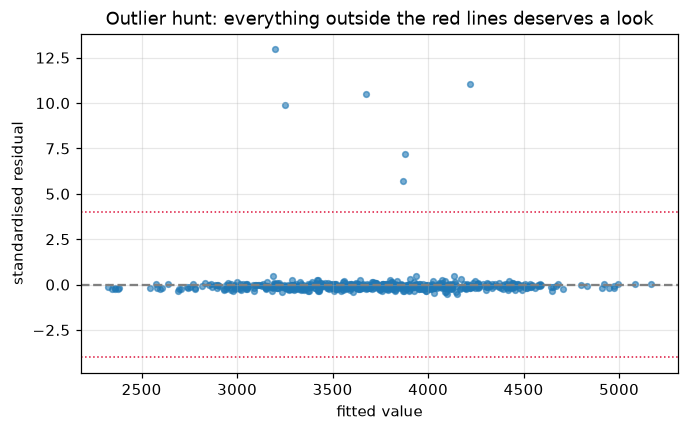

In [20]:
# Find them the way you would in real life: standardised residuals from a first-pass fit.
X_quick = SimpleImputer(strategy="median").fit_transform(messy[numeric_cols])
resid = y_messy - LinearRegression().fit(X_quick, y_messy).predict(X_quick)
std_resid = resid / resid.std()
suspects = np.abs(std_resid) > 4

print(f"rows more than 4 SD from the fit: {suspects.sum()}")
print(messy.loc[suspects, ["sqft", "bedrooms", "district", "rent"]]
      .assign(std_resid=std_resid[suspects].round(1)).to_string())
print(f"\nmedian rent overall: {messy['rent'].median():,.0f}")
print("These are ~10x the typical rent for their size. Unit error, not a penthouse.")

plt.scatter(LinearRegression().fit(X_quick, y_messy).predict(X_quick), std_resid, s=14, alpha=.6)
plt.axhline(0, color="gray", ls="--")
for line in (-4, 4):
    plt.axhline(line, color="crimson", ls=":", lw=1)
plt.xlabel("fitted value"); plt.ylabel("standardised residual")
plt.title("Outlier hunt: everything outside the red lines deserves a look")
plt.grid(alpha=0.3); plt.show()

In [21]:
# What those 6 rows cost, and three ways to deal with them.
clean = ~suspects
X_clean, y_clean = X_quick[clean], y_messy[clean]

print(f"{'approach':<32} {'sqft coef':>11} {'RMSE on clean rows':>20}")
print("-" * 66)
for label, model in [
    ("OLS, outliers left in", LinearRegression().fit(X_quick, y_messy)),
    ("OLS, outliers removed", LinearRegression().fit(X_clean, y_clean)),
    ("Huber (robust loss)",   HuberRegressor(max_iter=500).fit(X_quick, y_messy)),
]:
    print(f"{label:<32} {model.coef_[0]:>11.3f} "
          f"{root_mean_squared_error(y_clean, model.predict(X_clean)):>20.1f}")

print("\ntrue sqft coefficient: 2.200")
print()
print("Leaving them in wrecks the coefficient. Removing them recovers it. Huber recovers")
print("it too WITHOUT deleting anything - it down-weights points that do not fit rather")
print("than trusting them fully. That is what you want when you cannot be certain a weird")
print("row is an error and not a real rare case.")

approach                           sqft coef   RMSE on clean rows
------------------------------------------------------------------
OLS, outliers left in                  1.571                468.8
OLS, outliers removed                  2.180                342.1
Huber (robust loss)                    2.187                342.3

true sqft coefficient: 2.200

Leaving them in wrecks the coefficient. Removing them recovers it. Huber recovers
it too WITHOUT deleting anything - it down-weights points that do not fit rather
than trusting them fully. That is what you want when you cannot be certain a weird
row is an error and not a real rare case.


### Scalers and outliers

| Scaler | Formula | Use when |
|---|---|---|
| `StandardScaler` | $(x-\mu)/\sigma$ | Default. Assumes roughly symmetric data. |
| `RobustScaler` | $(x-\text{median})/\text{IQR}$ | **Outliers present** — median and IQR barely move |
| `MinMaxScaler` | to $[0,1]$ | You need a bounded range; **very** outlier-sensitive |

In [22]:
col = messy.loc[clean.to_numpy(), "sqft"].fillna(messy["sqft"].median()).to_numpy().reshape(-1, 1)
contaminated = np.vstack([col, [[50_000]]])          # one absurd row

print(f"{'scaler':<18} {'range of the 600 real rows after scaling':>44}")
print("-" * 64)
for name, scaler in [("StandardScaler", StandardScaler()),
                     ("RobustScaler", RobustScaler()),
                     ("MinMaxScaler", MinMaxScaler())]:
    scaled = scaler.fit_transform(contaminated)[:-1]
    print(f"{name:<18} {f'[{scaled.min():.3f}, {scaled.max():.3f}]':>44}")
print()
print("MinMaxScaler squashes every real row into a sliver near 0 - one bad value defines")
print("the whole range, so 600 genuine rows share 3% of the output scale.")
print()
print("StandardScaler is damaged too, and less obviously: the outlier inflates the standard")
print("deviation it divides by, so the real rows are compressed into a narrow band as well.")
print()
print("RobustScaler barely notices, because a median and an IQR do not move when one point")
print("flies off to infinity. That is the whole reason it exists.")

scaler                 range of the 600 real rows after scaling
----------------------------------------------------------------
StandardScaler                                  [-0.330, 0.326]
RobustScaler                                    [-2.360, 3.022]
MinMaxScaler                                     [0.000, 0.027]

MinMaxScaler squashes every real row into a sliver near 0 - one bad value defines
the whole range, so 600 genuine rows share 3% of the output scale.

StandardScaler is damaged too, and less obviously: the outlier inflates the standard
deviation it divides by, so the real rows are compressed into a narrow band as well.

RobustScaler barely notices, because a median and an IQR do not move when one point
flies off to infinity. That is the whole reason it exists.


## 5.3 Encoding categorical features

| Encoder | Produces | Use when |
|---|---|---|
| `OneHotEncoder` | One binary column per level | Default. Few levels, no natural order. |
| `OrdinalEncoder` | One integer column | There is a **real order** (small < medium < large), or you are feeding a tree |
| `TargetEncoder` | Level → mean of `y` | Very high cardinality (postcodes, product ids). **Must be inside CV** — it uses `y`. |

**The dummy-variable trap:** one-hot encode a 3-level category into 3 columns *and* fit an
intercept, and those 3 columns sum to exactly 1 in every row — which is the intercept column.
That is perfect collinearity: $X^\top X$ is singular and the coefficients become arbitrary.
`drop="first"` fixes it, and the dropped level becomes the **reference category**.

Caveats: only drop for *unregularised linear* models. With regularisation, dropping makes the
penalty depend on which level you dropped; trees do not care either way.

In [23]:
levels = np.array([["small"], ["medium"], ["large"]] * 12)
effect = {"small": 100.0, "medium": 150.0, "large": 220.0}
rng = np.random.default_rng(5)
y_cat = np.array([effect[v[0]] for v in levels]) + rng.normal(0, 5, len(levels))

# (a) all three levels kept + an intercept -> the trap
X_full = OneHotEncoder(sparse_output=False).fit_transform(levels)
print("row sums (always 1.0 - this IS the intercept column):", np.unique(X_full.sum(axis=1)))
trap = LinearRegression().fit(X_full, y_cat)
print(f"R2 = {trap.score(X_full, y_cat):.4f}  <- predictions are perfectly fine")
print("coefficients:", np.round(trap.coef_, 2), " intercept:", round(trap.intercept_, 2))

# Shift every coefficient by a constant and absorb it in the intercept: identical predictions.
shifted = X_full @ (trap.coef_ + 40) + (trap.intercept_ - 40)
print("\nshift all coefs +40, intercept -40 -> predictions identical:",
      np.allclose(shifted, trap.predict(X_full)))
print("-> infinitely many coefficient sets fit equally well; sklearn returned one of them.")

# (b) drop one level -> unique, interpretable
enc = OneHotEncoder(drop="first", sparse_output=False).fit(levels)
clean_fit = LinearRegression().fit(enc.transform(levels), y_cat)
reference = enc.categories_[0][0]
print(f"\ndrop='first' -> reference category is '{reference}'")
print(f"  intercept {clean_fit.intercept_:.1f}  (the mean for '{reference}')")
for nm, c in zip(enc.get_feature_names_out(["size"]), clean_fit.coef_):
    print(f"  {nm:<14} {c:+8.1f}  (difference from '{reference}')")
print(f"\ntrue effects {effect}; 'large' - 'small' = {effect['large']-effect['small']:.0f}")

row sums (always 1.0 - this IS the intercept column): [1.]
R2 = 0.9932  <- predictions are perfectly fine
coefficients: [ 62.52  -5.72 -56.8 ]  intercept: 155.34

shift all coefs +40, intercept -40 -> predictions identical: True
-> infinitely many coefficient sets fit equally well; sklearn returned one of them.

drop='first' -> reference category is 'large'
  intercept 217.9  (the mean for 'large')
  size_medium       -68.2  (difference from 'large')
  size_small       -119.3  (difference from 'large')

true effects {'small': 100.0, 'medium': 150.0, 'large': 220.0}; 'large' - 'small' = 120


---
# Part 6 - Feature engineering

Swapping Ridge for Lasso moves your score by a percent. **Building the right feature moves it
by ten.** This matters most for linear models, which cannot discover non-linear structure on
their own, but interactions and good ratios help tree models too.

| Move | When | Example |
|---|---|---|
| **Log a skewed feature** | Right-skewed, spans orders of magnitude | `np.log1p(income)` |
| **Ratios** | The meaning is per-something | `sqft / bedrooms`, `debt / income` |
| **Interactions** | The effect of A depends on B | `is_furnished * sqft` |
| **Date parts** | Any timestamp | hour, day-of-week, month, is_weekend |
| **Cyclical encoding** | Wrap-around quantities | `sin(2πh/24)`, `cos(2πh/24)` |
| **Aggregations** | One-to-many relationships | mean/max/count per customer |

**The discipline:** measure every engineered feature with cross-validation and *delete* the
ones that do not pay. Feature engineering without measurement is adding columns and hoping —
and every useless column costs you variance.

In [24]:
# The baseline must already contain every MAIN effect, or an "interaction" added later
# gets credit for a main effect the baseline was simply missing. Easy mistake, big lie.
ok = ~suspects
X_ok = X_messy[ok.to_numpy()]
y_ok = y_messy[ok]

base = X_ok[numeric_cols].copy()
base["furnished_yes"] = (X_ok["furnished"] == "yes").astype(float)

variants = {"raw features (all main effects)": base}

v = base.copy()
v["log_transit"] = np.log1p(v["transit_score"])          # diminishing returns
variants["+ log1p(transit_score)"] = v

v = v.copy()
v["sqft_per_bedroom"] = v["sqft"] / v["bedrooms"]        # a ratio with real meaning
variants["+ sqft per bedroom"] = v

v = v.copy()
v["furnished_x_sqft"] = v["furnished_yes"] * v["sqft"].fillna(v["sqft"].median())
variants["+ furnished x sqft"] = v

print(f"{'feature set':<34} {'CV RMSE':>9} {'vs baseline':>13}")
print("-" * 58)
baseline = None
for label, fr in variants.items():
    score = -cross_val_score(
        make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0)),
        fr, y_ok, cv=cv5, scoring="neg_root_mean_squared_error").mean()
    delta = "" if baseline is None else f"{(score - baseline) / baseline:+.1%}"
    baseline = score if baseline is None else baseline
    print(f"{label:<34} {score:>9.1f} {delta:>13}")

print()
print("The log term is the win, and no amount of hyperparameter tuning would have found")
print("it - the model cannot invent a feature you did not give it. It works because it")
print("matches how the data was really generated: transit score has DIMINISHING returns,")
print("a shape a raw linear term cannot express at all.")
print()
print("The ratio and interaction add nothing here. On real data you do not know in")
print("advance, so you try them and let cross-validation decide.")

feature set                          CV RMSE   vs baseline
----------------------------------------------------------
raw features (all main effects)        324.0              
+ log1p(transit_score)                 307.6         -5.1%
+ sqft per bedroom                     307.4         -5.1%
+ furnished x sqft                     307.9         -5.0%

The log term is the win, and no amount of hyperparameter tuning would have found
it - the model cannot invent a feature you did not give it. It works because it
matches how the data was really generated: transit score has DIMINISHING returns,
a shape a raw linear term cannot express at all.

The ratio and interaction add nothing here. On real data you do not know in
advance, so you try them and let cross-validation decide.


In [25]:
# Cyclical encoding - the one that surprises people.
rng = np.random.default_rng(1)
hour = rng.integers(0, 24, 900)
demand = 100 + 40 * np.cos(2 * np.pi * hour / 24) + rng.normal(0, 5, 900)   # peaks at midnight

naive = pd.DataFrame({"hour": hour})
cyclical = pd.DataFrame({"hour_sin": np.sin(2 * np.pi * hour / 24),
                         "hour_cos": np.cos(2 * np.pi * hour / 24)})
one_hot = pd.get_dummies(pd.Series(hour, name="h").astype("category"), drop_first=True)

for label, fr in [("hour as a number 0-23", naive),
                  ("hour as sin + cos", cyclical),
                  ("hour one-hot", one_hot)]:
    r2 = cross_val_score(LinearRegression(), fr, demand, cv=cv5, scoring="r2").mean()
    print(f"{label:<24} CV R2 = {r2:6.3f}   ({fr.shape[1]} column(s))")

print()
print("Hour-as-a-number is useless: a linear model can only fit a straight line through a")
print("quantity that wraps, and 23:00 -> 00:00 looks like a 23-hour jump instead of one.")
print("Two sin/cos columns capture the whole daily cycle. One-hot also works but costs 23")
print("columns and cannot interpolate between hours.")

hour as a number 0-23    CV R2 =  0.003   (1 column(s))
hour as sin + cos        CV R2 =  0.969   (2 column(s))
hour one-hot             CV R2 =  0.967   (23 column(s))

Hour-as-a-number is useless: a linear model can only fit a straight line through a
quantity that wraps, and 23:00 -> 00:00 looks like a 23-hour jump instead of one.
Two sin/cos columns capture the whole daily cycle. One-hot also works but costs 23
columns and cannot interpolate between hours.


## 6.1 Transforming the target

If your target is right-skewed — prices, incomes, counts, durations, anything bounded below
by zero with a long tail — a model fitted on the raw target will put most of its effort into
the few huge values, leave a residual funnel, and sometimes predict negatives.

Fitting `log(y)` converts *multiplicative* error into *additive* error, which is what squared
error assumes. `TransformedTargetRegressor` wires the inverse transform back in automatically
— including inside cross-validation, where doing it by hand is easy to get wrong.

target: min 7, median 59, max 903  <- max is 15x the median
raw target     CV RMSE     54.6   CV MAE     34.4
log1p target   CV RMSE     46.3   CV MAE     25.2


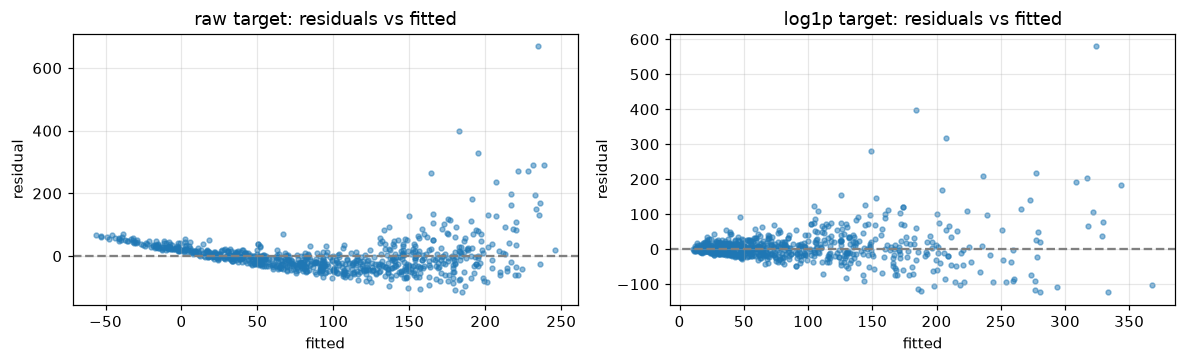

MAE improves much more than RMSE. Fitting in log space optimises RELATIVE error, so
it wins on typical rows and gives up a little on the few enormous ones that dominate
RMSE. Which you want depends on whether being 20% off matters equally at every scale.


In [26]:
rng = np.random.default_rng(11)
n_skew = 800
x1, x2 = rng.uniform(1, 10, n_skew), rng.uniform(0, 5, n_skew)
y_skew = np.exp(0.3 * x1 + 0.2 * x2 + 2) * rng.lognormal(0, 0.35, n_skew)   # multiplicative noise
X_skew = pd.DataFrame({"x1": x1, "x2": x2})

print(f"target: min {y_skew.min():.0f}, median {np.median(y_skew):.0f}, max {y_skew.max():.0f}"
      f"  <- max is {y_skew.max()/np.median(y_skew):.0f}x the median")

plain = make_pipeline(StandardScaler(), LinearRegression())
logged = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), LinearRegression()),
    func=np.log1p, inverse_func=np.expm1,
)
for label, model in [("raw target", plain), ("log1p target", logged)]:
    rmse = -cross_val_score(model, X_skew, y_skew, cv=cv5,
                            scoring="neg_root_mean_squared_error").mean()
    mae = -cross_val_score(model, X_skew, y_skew, cv=cv5,
                           scoring="neg_mean_absolute_error").mean()
    print(f"{label:<14} CV RMSE {rmse:8.1f}   CV MAE {mae:8.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (label, model) in zip(axes, [("raw target", plain), ("log1p target", logged)]):
    pred = model.fit(X_skew, y_skew).predict(X_skew)
    ax.scatter(pred, y_skew - pred, s=10, alpha=0.5)
    ax.axhline(0, color="gray", ls="--")
    ax.set(xlabel="fitted", ylabel="residual", title=f"{label}: residuals vs fitted")
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("MAE improves much more than RMSE. Fitting in log space optimises RELATIVE error, so")
print("it wins on typical rows and gives up a little on the few enormous ones that dominate")
print("RMSE. Which you want depends on whether being 20% off matters equally at every scale.")

### The retransformation trap

`log1p` / `expm1` gives you back the **median** of the predicted distribution, not the mean,
because $E[e^Z] \neq e^{E[Z]}$ (Jensen's inequality).

For ranking, per-unit budgeting or "typical value" questions the median is what you want.
If your predictions must **sum** correctly — total revenue across 10,000 customers — the
median systematically under-totals, and you need a correction: multiply by $e^{\sigma^2/2}$
under log-normality, or use Duan's smearing estimator.

This is the kind of detail that separates a model that looks fine in a notebook from one
whose forecasts reconcile with finance's numbers.

---
# Part 7 - Metrics

**An error metric alone is never interpretable.** It needs a baseline, or a scale, or both.
"RMSE 50,000" is meaningless until you know whether the target's standard deviation is
55,000 or 500,000.

## 7.1 Regression metrics

| Metric | Formula | Units | Reads as |
|---|---|---|---|
| **MAE** | $\frac{1}{n}\sum\lvert y-\hat{y}\rvert$ | target's | "typical miss", robust to outliers |
| **MSE** | $\frac{1}{n}\sum(y-\hat{y})^2$ | target's, **squared** | the thing most models minimise |
| **RMSE** | $\sqrt{\text{MSE}}$ | target's | "typical miss", punishes large errors |
| **R²** | $1 - SS_{res}/SS_{tot}$ | none | fraction of variance explained |
| **MAPE** | $\frac{100}{n}\sum\lvert (y-\hat{y})/y\rvert$ | % | intuitive, **undefined at $y=0$** |

**R² compares your model to the dumbest possible one** — always predicting the mean:

$$ R^2 = 1 - \frac{\text{your squared error}}{\text{the mean-predictor's squared error}} $$

so $R^2=0$ means "no better than the mean" and $R^2<0$ means **worse than the mean**.
Negative R² is impossible on training data with an intercept, and entirely possible on test
data — if you see it, something is badly wrong (overfitting, distribution shift, or a broken
pipeline).

In [27]:
def regression_metrics(y_true, y_pred):
    """All of them, computed from scratch, so nothing is hidden behind a library call."""
    r = y_true - y_pred
    ss_res = np.sum(r ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)      # the mean-predictor's error
    return {
        "MAE":  np.mean(np.abs(r)),
        "MSE":  np.mean(r ** 2),
        "RMSE": np.sqrt(np.mean(r ** 2)),
        "R2":   1 - ss_res / ss_tot,
    }


pred_r = model_r.predict(Xr_te)
mine = regression_metrics(yr_te.to_numpy(), pred_r)
print("from scratch:", {k: round(float(v), 4) for k, v in mine.items()})
print("scikit-learn:", {
    "MAE":  round(mean_absolute_error(yr_te, pred_r), 4),
    "MSE":  round(mean_squared_error(yr_te, pred_r), 4),
    "RMSE": round(root_mean_squared_error(yr_te, pred_r), 4),
    "R2":   round(r2_score(yr_te, pred_r), 4),
})
print()
print(f"target std on test: {yr_te.std():.2f}")
print(f"RMSE / target std : {mine['RMSE'] / yr_te.std():.2f}   <- this ratio is what makes")
print("RMSE interpretable. Near 1.0 means you are barely beating the mean.")

from scratch: {'MAE': 42.812, 'MSE': 2892.0146, 'RMSE': 53.7775, 'R2': 0.4541}
scikit-learn: {'MAE': 42.812, 'MSE': 2892.0146, 'RMSE': 53.7775, 'R2': 0.4541}

target std on test: 73.20
RMSE / target std : 0.73   <- this ratio is what makes
RMSE interpretable. Near 1.0 means you are barely beating the mean.


## 7.2 Classification metrics

Everything starts from the confusion matrix.

```
                    predicted
                  neg        pos
actual  neg  [   TN    |    FP   ]   FP = false alarm      (type I error)
        pos  [   FN    |    TP   ]   FN = missed positive  (type II error)
```

| Metric | Formula | Answers |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{\text{all}}$ | "how often right?" — **lies on imbalanced data** |
| **Precision** | $\frac{TP}{TP+FP}$ | of those we flagged, how many were real? (cost of false alarms) |
| **Recall** (sensitivity, TPR) | $\frac{TP}{TP+FN}$ | of the real ones, how many did we catch? (cost of misses) |
| **F1** | harmonic mean of the two | one number when both matter equally |
| **ROC-AUC** | area under TPR vs FPR | threshold-free *ranking* quality |
| **PR-AUC** (average precision) | area under precision vs recall | ranking quality **when positives are rare** |
| **Log-loss** | $-\frac1n\sum[y\log p + (1-y)\log(1-p)]$ | were the *probabilities* good? |
| **Brier score** | $\frac1n\sum(p-y)^2$ | calibration + sharpness in one number |

**Precision and recall trade off against each other** and you cannot maximise both. Which one
you favour is a *business* decision, not a statistical one.

In [28]:
proba_c = model_c.predict_proba(Xc_te)[:, 1]
pred_c = model_c.predict(Xc_te)

tn, fp, fn, tp = confusion_matrix(yc_te, pred_c).ravel()
print("confusion matrix at the default 0.5 threshold")
print(f"                 predicted neg   predicted pos")
print(f"  actual neg  {tn:>12}   {fp:>13}")
print(f"  actual pos  {fn:>12}   {tp:>13}")
print()
print(f"  accuracy  {(tp+tn)/(tp+tn+fp+fn):.4f}   <- inflated by the {tn} easy negatives")
print(f"  precision {tp/(tp+fp) if tp+fp else 0:.4f}   = TP/(TP+FP)")
print(f"  recall    {tp/(tp+fn):.4f}   = TP/(TP+FN)")
print(f"  F1        {f1_score(yc_te, pred_c):.4f}")
print(f"  ROC-AUC   {roc_auc_score(yc_te, proba_c):.4f}   threshold-free")
print(f"  PR-AUC    {average_precision_score(yc_te, proba_c):.4f}   <- compare to the {yc_te.mean():.3f} base rate")
print(f"  log-loss  {log_loss(yc_te, proba_c):.4f}")
print()
print(classification_report(yc_te, pred_c, target_names=["negative", "positive"], digits=3))
print("Always read the rare class's ROW, not the overall accuracy. 'support' is how many")
print("real examples of each class exist - a metric over 50 rows is not worth 3 decimals.")

confusion matrix at the default 0.5 threshold
                 predicted neg   predicted pos
  actual neg           941               3
  actual pos            51               5

  accuracy  0.9460   <- inflated by the 941 easy negatives
  precision 0.6250   = TP/(TP+FP)
  recall    0.0893   = TP/(TP+FN)
  F1        0.1562
  ROC-AUC   0.8341   threshold-free
  PR-AUC    0.4190   <- compare to the 0.056 base rate
  log-loss  0.1668

              precision    recall  f1-score   support

    negative      0.949     0.997     0.972       944
    positive      0.625     0.089     0.156        56

    accuracy                          0.946      1000
   macro avg      0.787     0.543     0.564      1000
weighted avg      0.930     0.946     0.926      1000

Always read the rare class's ROW, not the overall accuracy. 'support' is how many
real examples of each class exist - a metric over 50 rows is not worth 3 decimals.


### ROC-AUC vs PR-AUC on imbalanced data

ROC-AUC's x-axis is the **false positive rate**, $FP/(FP+TN)$. When negatives massively
outnumber positives, that denominator is enormous, so even a lot of false positives barely
move the curve — and ROC-AUC looks flattering.

PR-AUC uses **precision**, $TP/(TP+FP)$, which has no $TN$ in it at all. It cannot be
flattered by an abundance of easy negatives. Its baseline is the positive rate, not 0.5.

**Rule:** if the positive class is rare and you care about it, report PR-AUC.

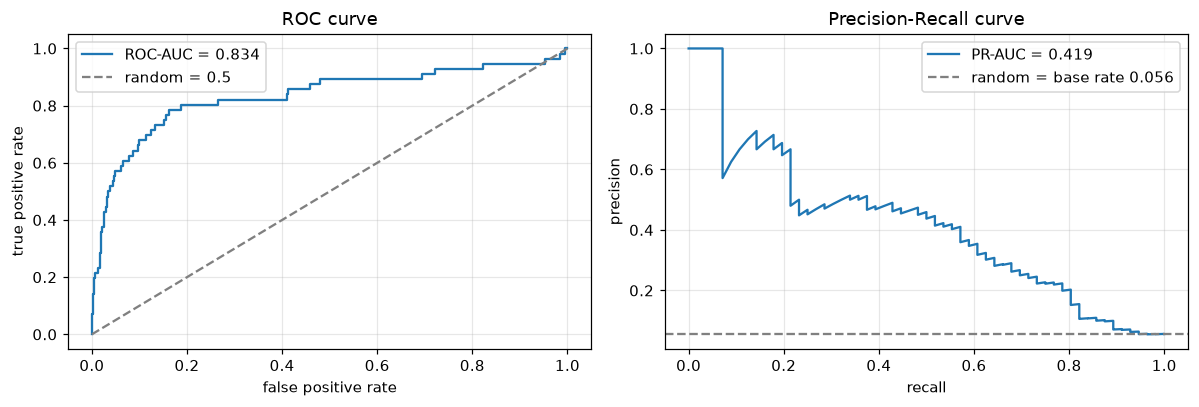

Note the two 'random' baselines: ROC's is 0.5 whatever the class balance, but PR's
is the base rate itself (0.056).

So for this model:  ROC-AUC 0.834 is 1.7x its random baseline,
                    PR-AUC  0.419 is 7.5x its random baseline.

The PR number is the smaller-sounding one and the more informative one. ROC-AUC
gets to count the 944 easy negatives as successes; PR-AUC does not, because
precision has no true-negative term in it at all.


In [29]:
fpr, tpr, _ = roc_curve(yc_te, proba_c)
prec, rec, _ = precision_recall_curve(yc_te, proba_c)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(yc_te, proba_c):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="random = 0.5")
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC curve")
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(rec, prec, label=f"PR-AUC = {average_precision_score(yc_te, proba_c):.3f}")
axes[1].axhline(yc_te.mean(), ls="--", color="gray",
                label=f"random = base rate {yc_te.mean():.3f}")
axes[1].set(xlabel="recall", ylabel="precision", title="Precision-Recall curve")
axes[1].legend(); axes[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

roc = roc_auc_score(yc_te, proba_c)
pr = average_precision_score(yc_te, proba_c)
base_rate = yc_te.mean()
print("Note the two 'random' baselines: ROC's is 0.5 whatever the class balance, but PR's")
print(f"is the base rate itself ({base_rate:.3f}).")
print()
print(f"So for this model:  ROC-AUC {roc:.3f} is {roc/0.5:.1f}x its random baseline,")
print(f"                    PR-AUC  {pr:.3f} is {pr/base_rate:.1f}x its random baseline.")
print()
print("The PR number is the smaller-sounding one and the more informative one. ROC-AUC")
print("gets to count the 944 easy negatives as successes; PR-AUC does not, because")
print("precision has no true-negative term in it at all.")

## 7.3 The threshold is not part of the model

`predict()` applies a hard-coded 0.5 cut to `predict_proba()`. That 0.5 is a **default, not a
decision** — and it is almost never the right one on imbalanced data.

Separating the two is the important idea:

- the **model** produces a score / probability — evaluate it with ROC-AUC, PR-AUC, log-loss
- the **threshold** turns that score into an action — choose it from the *cost* of each error

And tune it on **validation** data, never the test set (Part 3.5).

In [30]:
# Sweep the threshold on a validation split carved out of TRAINING data.
Xc_fit, Xc_val, yc_fit, yc_val = train_test_split(
    Xc_tr, yc_tr, test_size=0.25, stratify=yc_tr, random_state=RANDOM_STATE
)
m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_fit, yc_fit)
val_proba = m.predict_proba(Xc_val)[:, 1]

grid = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(yc_val, (val_proba >= t).astype(int), zero_division=0) for t in grid]
best_t = grid[int(np.argmax(f1s))]

te_proba = m.predict_proba(Xc_te)[:, 1]
print(f"{'threshold':<28} {'precision':>10} {'recall':>8} {'F1':>8}")
print("-" * 58)
for label, t in [("default 0.5", 0.5), (f"F1-tuned on validation ({best_t:.2f})", best_t)]:
    p = (te_proba >= t).astype(int)
    print(f"{label:<28} {precision_score(yc_te, p, zero_division=0):>10.3f} "
          f"{recall_score(yc_te, p):>8.3f} {f1_score(yc_te, p):>8.3f}")

print(f"\nROC-AUC is identical either way ({roc_auc_score(yc_te, te_proba):.4f}) - it is")
print("mathematically incapable of noticing a threshold, because it integrates over all")
print("of them. That is what makes it a MODEL metric rather than a DECISION metric.")

threshold                     precision   recall       F1
----------------------------------------------------------
default 0.5                       0.727    0.143    0.239
F1-tuned on validation (0.14)      0.371    0.589    0.455

ROC-AUC is identical either way (0.8256) - it is
mathematically incapable of noticing a threshold, because it integrates over all
of them. That is what makes it a MODEL metric rather than a DECISION metric.


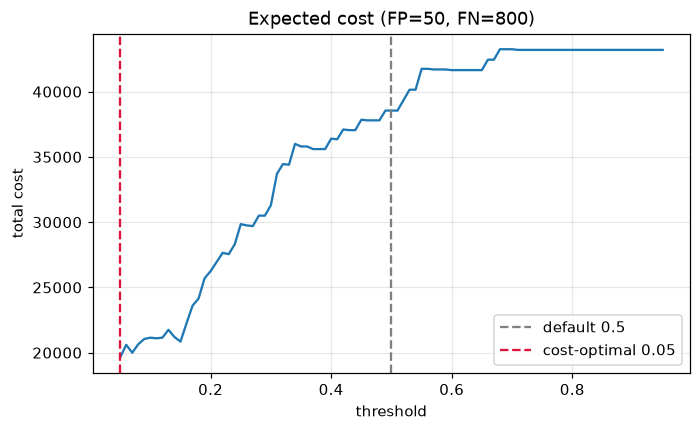

cost at default 0.5      : 38,550
cost at cost-optimal 0.05: 19,650

When a miss costs 16x a false alarm, the optimal threshold drops well below 0.5 -
you deliberately accept more false alarms to catch more positives.

sklearn automates the search: TunedThresholdClassifierCV(estimator, scoring=...)
picks the threshold by cross-validation, inside the training data, leak-free.


In [31]:
# Cost-based thresholding: the version a business actually wants.
COST_FP = 50      # wasted retention offer
COST_FN = 800     # a lost customer

costs = [((te_proba >= t).astype(int) != yc_te).astype(int) for t in grid]
total = []
for t in grid:
    p = (te_proba >= t).astype(int)
    fp_ = int(((p == 1) & (yc_te == 0)).sum())
    fn_ = int(((p == 0) & (yc_te == 1)).sum())
    total.append(fp_ * COST_FP + fn_ * COST_FN)
total = np.array(total)
best_cost_t = grid[int(total.argmin())]

plt.plot(grid, total)
plt.axvline(0.5, ls="--", color="gray", label="default 0.5")
plt.axvline(best_cost_t, ls="--", color="crimson", label=f"cost-optimal {best_cost_t:.2f}")
plt.xlabel("threshold"); plt.ylabel("total cost")
plt.title(f"Expected cost (FP={COST_FP}, FN={COST_FN})")
plt.legend(); plt.grid(alpha=.3); plt.show()

print(f"cost at default 0.5      : {total[np.argmin(np.abs(grid - 0.5))]:,}")
print(f"cost at cost-optimal {best_cost_t:.2f}: {total.min():,}")
print()
print("When a miss costs 16x a false alarm, the optimal threshold drops well below 0.5 -")
print("you deliberately accept more false alarms to catch more positives.")
print()
print("sklearn automates the search: TunedThresholdClassifierCV(estimator, scoring=...)")
print("picks the threshold by cross-validation, inside the training data, leak-free.")

In [32]:
tuned = TunedThresholdClassifierCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    scoring="f1", cv=5, random_state=RANDOM_STATE,
).fit(Xc_tr, yc_tr)

print(f"threshold chosen by CV      : {tuned.best_threshold_:.3f}")
print(f"threshold from our manual sweep: {best_t:.3f}")
print(f"test F1 (CV-tuned)          : {f1_score(yc_te, tuned.predict(Xc_te)):.4f}")
print()
print("Two honest procedures landing near the same threshold is the sanity check. If the")
print("manual number had disagreed wildly with the CV number, one of them was leaking.")

threshold chosen by CV      : 0.190
threshold from our manual sweep: 0.140
test F1 (CV-tuned)          : 0.4786

Two honest procedures landing near the same threshold is the sanity check. If the
manual number had disagreed wildly with the CV number, one of them was leaking.


## 7.4 Calibration: are the probabilities real?

A model can rank perfectly (AUC 1.0) while its probabilities are nonsense. If you only need
an ordering — who to call first — that is fine. The moment you do **expected-value maths**
(`P(churn) × customer_value`), you need probabilities that mean what they say.

"Calibrated" means: of all the cases where the model said 0.7, about 70% really were
positive.

**Things that break calibration:** `class_weight='balanced'`, resampling/SMOTE, and most
tree ensembles (they push probabilities toward the middle). Fix with
`CalibratedClassifierCV` (`method="sigmoid"` = Platt scaling, `"isotonic"` = non-parametric,
needs more data).

model                         Brier   log-loss   ROC-AUC
--------------------------------------------------------
random forest (raw)          0.0344     0.1280    0.9167
+ isotonic calibration       0.0321     0.1201    0.9099


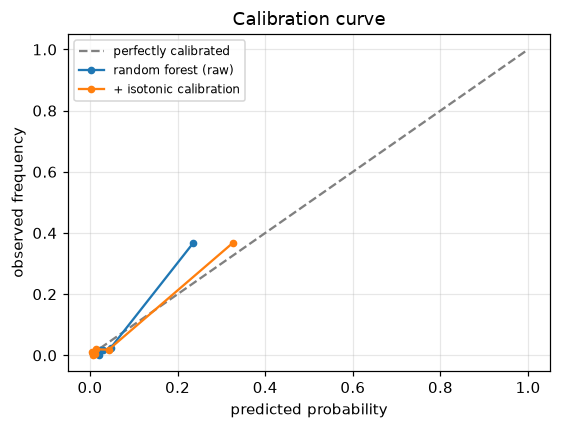


Watch what changes and what does not: Brier and log-loss improve, ROC-AUC barely
moves. Calibration rescales the probabilities without reordering them - so it
cannot improve ranking, and ranking metrics cannot detect that it happened.


In [33]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                            random_state=RANDOM_STATE).fit(Xc_fit, yc_fit)
cal = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
    method="isotonic", cv=5,
).fit(Xc_fit, yc_fit)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfectly calibrated")
print(f"{'model':<26} {'Brier':>8} {'log-loss':>10} {'ROC-AUC':>9}")
print("-" * 56)
for label, m_ in [("random forest (raw)", rf), ("+ isotonic calibration", cal)]:
    p = m_.predict_proba(Xc_te)[:, 1]
    frac_pos, mean_pred = calibration_curve(yc_te, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", ms=4, label=label)
    print(f"{label:<26} {brier_score_loss(yc_te, p):>8.4f} {log_loss(yc_te, p):>10.4f} "
          f"{roc_auc_score(yc_te, p):>9.4f}")

ax.set(xlabel="predicted probability", ylabel="observed frequency",
       title="Calibration curve")
ax.legend(fontsize=8); ax.grid(alpha=.3); fig.tight_layout(); plt.show()

print()
print("Watch what changes and what does not: Brier and log-loss improve, ROC-AUC barely")
print("moves. Calibration rescales the probabilities without reordering them - so it")
print("cannot improve ranking, and ranking metrics cannot detect that it happened.")

---
# Part 8 - Hyperparameter tuning

**Parameters** are learned from data (`coef_`). **Hyperparameters** are chosen by you
(`alpha`, `max_depth`, `C`) and control the bias-variance trade-off.

| Search | How it works | Use when |
|---|---|---|
| `GridSearchCV` | Every combination | Few parameters, small discrete grids |
| `RandomizedSearchCV` | `n_iter` random draws from distributions | **The default for more than ~2 parameters** |
| `HalvingGridSearchCV` | Successive halving: many candidates on little data, survivors on more | Large search spaces, expensive fits |

**Tune on a log scale.** Penalty strengths and learning rates span orders of magnitude —
`[1, 2, 3, 4, 5]` is nearly useless; `np.logspace(-3, 3, 13)` is what you want.

best alpha   : 31.6228
best CV RMSE : 55.805
test RMSE    : 53.493

grid.best_estimator_ is a fully-fitted pipeline, ready to use.


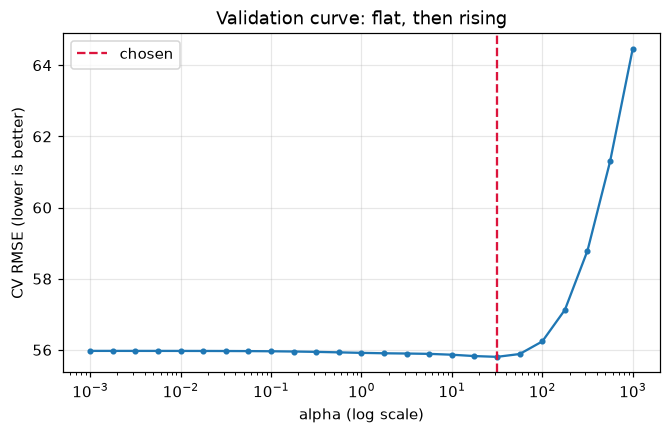

A FLAT curve means the hyperparameter barely matters on this data - useful to know
before you spend an hour tuning it. A sharp minimum means it matters a lot, and
that you should check your grid was wide enough to contain the true optimum.


In [34]:
pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge())])

# Parameter names are "<step name>__<parameter>" - a DOUBLE underscore.
grid = GridSearchCV(
    pipe,
    param_grid={"model__alpha": np.logspace(-3, 3, 25)},
    cv=5, scoring="neg_root_mean_squared_error",
).fit(Xr_tr, yr_tr)

print(f"best alpha   : {grid.best_params_['model__alpha']:.4f}")
print(f"best CV RMSE : {-grid.best_score_:.3f}")
print(f"test RMSE    : {root_mean_squared_error(yr_te, grid.predict(Xr_te)):.3f}")
print("\ngrid.best_estimator_ is a fully-fitted pipeline, ready to use.")

res = pd.DataFrame(grid.cv_results_)
plt.semilogx(res["param_model__alpha"].astype(float), -res["mean_test_score"], marker=".")
plt.axvline(grid.best_params_["model__alpha"], ls="--", color="crimson", label="chosen")
plt.xlabel("alpha (log scale)"); plt.ylabel("CV RMSE (lower is better)")
plt.title("Validation curve: flat, then rising"); plt.legend(); plt.grid(alpha=.3); plt.show()

print("A FLAT curve means the hyperparameter barely matters on this data - useful to know")
print("before you spend an hour tuning it. A sharp minimum means it matters a lot, and")
print("that you should check your grid was wide enough to contain the true optimum.")

In [35]:
# All three searches on the same space, timed, so the trade-offs are visible.
import time

param_space = {
    "model__max_depth":        [2, 3, 5],
    "model__learning_rate":    [0.03, 0.1, 0.3],
    "model__max_leaf_nodes":   [7, 15, 31],
    "model__min_samples_leaf": [5, 20],
}
n_combos = int(np.prod([len(v) for v in param_space.values()]))
gb_pipe = Pipeline([("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE,
                                                            max_iter=60))])

print(f"the grid has {n_combos} combinations; at cv=3 an exhaustive search is "
      f"{n_combos*3} fits\n")
print(f"{'search':<26} {'seconds':>9} {'best CV RMSE':>14}")
print("-" * 52)

searches = [
    ("GridSearchCV (exhaustive)",
     GridSearchCV(gb_pipe, param_space, cv=3, scoring="neg_root_mean_squared_error")),
    ("RandomizedSearchCV (15)",
     RandomizedSearchCV(gb_pipe, param_space, n_iter=15, cv=3,
                        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE)),
    ("HalvingGridSearchCV",
     HalvingGridSearchCV(gb_pipe, param_space, cv=3, factor=3,
                         scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE)),
]
timings, scores = {}, {}
for label, search in searches:
    t0 = time.time()
    search.fit(Xr_tr, yr_tr)
    timings[label], scores[label] = time.time() - t0, -search.best_score_
    print(f"{label:<26} {timings[label]:>9.1f} {scores[label]:>14.2f}")

grid_label, rand_label, halve_label = [lbl for lbl, _ in searches]
print()
print(f"Randomized search sampled 15 of {n_combos} combinations and matched the exhaustive")
print(f"grid's optimum ({scores[rand_label]:.2f} vs {scores[grid_label]:.2f}) in "
      f"{timings[rand_label]/timings[grid_label]:.0%} of the time.")
print("That is the usual outcome, and it gets more pronounced as you add hyperparameters:")
print("a grid spends most of its budget varying parameters that turn out not to matter,")
print("while random sampling spreads its draws across every dimension at once.")
print()
print(f"Halving landed on a WORSE optimum ({scores[halve_label]:.2f}). That is its documented")
print("trade-off: it eliminates most candidates after evaluating them on a small subset of")
print("the data, so a candidate that only shines on the full dataset can be discarded early.")
print()
print("Note it also saved little or no time here - on a grid this small there is not enough")
print("work for the successive-halving overhead to pay for itself. Halving is for the case")
print("this cell is too small to show: hundreds of candidates and genuinely expensive fits.")
print("Reach for it then, not as a free upgrade.")

the grid has 54 combinations; at cv=3 an exhaustive search is 162 fits

search                       seconds   best CV RMSE
----------------------------------------------------
GridSearchCV (exhaustive)       10.6          58.28
RandomizedSearchCV (15)          2.9          58.28
HalvingGridSearchCV             10.5          63.93

Randomized search sampled 15 of 54 combinations and matched the exhaustive
grid's optimum (58.28 vs 58.28) in 27% of the time.
That is the usual outcome, and it gets more pronounced as you add hyperparameters:
a grid spends most of its budget varying parameters that turn out not to matter,
while random sampling spreads its draws across every dimension at once.

Halving landed on a WORSE optimum (63.93). That is its documented
trade-off: it eliminates most candidates after evaluating them on a small subset of
the data, so a candidate that only shines on the full dataset can be discarded early.

Note it also saved little or no time here - on a grid this small 

## 8.1 Nested cross-validation

Here is the subtle problem: if you use cross-validation to *choose* hyperparameters and then
report that same CV score, the score is optimistic. The search tried many configurations and
kept the one that scored best on those folds — it has fitted the folds.

**Nested CV** puts the whole search inside an outer CV loop, so the score is measured on data
the search never saw. Use it when you need an honest performance estimate *without* a
separate test set (typically on small data).

In [36]:
inner = KFold(4, shuffle=True, random_state=RANDOM_STATE)
outer = KFold(5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
                      {"model__alpha": np.logspace(-3, 3, 13)},
                      cv=inner, scoring="r2")

non_nested = search.fit(Xr, yr).best_score_
nested = cross_val_score(search, Xr, yr, cv=outer, scoring="r2").mean()

print(f"non-nested CV score (the search's own best): {non_nested:.4f}   <- optimistic")
print(f"nested CV score (search inside outer folds): {nested:.4f}   <- honest")
print(f"optimism from selection                    : {non_nested - nested:+.4f} R2")
print()
print("The gap is small here because we tuned ONE parameter over a smooth curve. Tune")
print("twelve parameters on 200 rows and the gap becomes large - and it is invisible")
print("unless you go nested, because both numbers come out of 'cross-validation'.")
print()
print("Cost: outer x inner fits. If you have a proper held-out test set, you do not need")
print("nested CV - the test set plays the role of the outer loop.")

non-nested CV score (the search's own best): 0.4807   <- optimistic
nested CV score (search inside outer folds): 0.4767   <- honest
optimism from selection                    : +0.0040 R2

The gap is small here because we tuned ONE parameter over a smooth curve. Tune
twelve parameters on 200 rows and the gap becomes large - and it is invisible
unless you go nested, because both numbers come out of 'cross-validation'.

Cost: outer x inner fits. If you have a proper held-out test set, you do not need
nested CV - the test set plays the role of the outer loop.


---
# Part 9 - Shipping and monitoring

Refit on **all** the data once measurement is done — the split existed to produce an honest
estimate, and now that you have it, more data gives a slightly better final model. Then
persist the **whole pipeline**, not just the estimator.

In [37]:
import joblib, os, tempfile, sklearn

production = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=grid.best_params_["model__alpha"])),
]).fit(Xr, yr)                                  # ALL the data, tuned alpha

bundle = {
    "pipeline": production,
    "features": list(Xr.columns),
    "trained_rows": len(Xr),
    "test_rmse": float(root_mean_squared_error(yr_te, grid.predict(Xr_te))),
    "sklearn_version": sklearn.__version__,
    "feature_ranges": {c: (float(Xr[c].min()), float(Xr[c].max())) for c in Xr.columns},
}

with tempfile.TemporaryDirectory() as d:
    path = os.path.join(d, "model.joblib")
    joblib.dump(bundle, path)
    reloaded = joblib.load(path)
    print(f"saved {os.path.getsize(path):,} bytes")
    print("keys:", list(reloaded.keys()))
    print("predictions identical after reload:",
          np.allclose(production.predict(Xr.head()), reloaded["pipeline"].predict(Xr.head())))

print()
print("Save the PIPELINE. If you save only the estimator you must remember to reproduce")
print("the exact scaling and encoding at inference time - a classic silent production bug.")
print()
print("Caveats: joblib files are version-sensitive (pin sklearn), and unpickling executes")
print("code - never load one from an untrusted source.")

saved 2,002 bytes
keys: ['pipeline', 'features', 'trained_rows', 'test_rmse', 'sklearn_version', 'feature_ranges']
predictions identical after reload: True

Save the PIPELINE. If you save only the estimator you must remember to reproduce
the exact scaling and encoding at inference time - a classic silent production bug.

Caveats: joblib files are version-sensitive (pin sklearn), and unpickling executes
code - never load one from an untrusted source.


In [38]:
def extrapolation_guard(train_ranges, X_new):
    """Flag rows outside the per-feature training range.

    Crude, but it catches most real cases and is trivially explainable to whoever is on
    call at 3am. For correlated features a Mahalanobis distance is stricter.
    """
    flags, why = [], []
    for _, row in X_new.iterrows():
        bad = [c for c in X_new.columns
               if c in train_ranges and not (train_ranges[c][0] <= row[c] <= train_ranges[c][1])]
        flags.append(bool(bad)); why.append(bad)
    return np.array(flags), why


queries = Xr.head(3).copy()
queries.iloc[0, queries.columns.get_loc("age")] = 5      # a 5-year-old patient
queries.iloc[1, queries.columns.get_loc("bmi")] = 90     # impossible BMI

flags, why = extrapolation_guard(bundle["feature_ranges"], queries)
preds = production.predict(queries)
for i, (f, w, p) in enumerate(zip(flags, why, preds)):
    status = f"REFUSE - {w} outside training range" if f else f"{p:.1f}"
    print(f"row {i}: {status}")

print()
print("A linear model will answer ANY question with total confidence, including about")
print("regions it has never seen. Nothing in .predict() warns you. In production: refuse,")
print("or serve with a loud low-confidence marker, or clip and say you clipped.")
print()
print("And MONITOR THE FLAG RATE. A rising fraction of out-of-range inputs is the earliest")
print("warning you get that your training data has gone stale.")

row 0: REFUSE - ['age'] outside training range
row 1: REFUSE - ['bmi'] outside training range
row 2: 173.3

A linear model will answer ANY question with total confidence, including about
regions it has never seen. Nothing in .predict() warns you. In production: refuse,
or serve with a loud low-confidence marker, or clip and say you clipped.

And MONITOR THE FLAG RATE. A rising fraction of out-of-range inputs is the earliest
warning you get that your training data has gone stale.


### What to monitor after shipping

| Watch | Why | Action if it moves |
|---|---|---|
| Input feature distributions | Covariate drift — the population changed | Retrain |
| Prediction distribution | Output drifting even if inputs look stable | Investigate |
| Realised error, once labels arrive | The only ground truth | Retrain or rebuild |
| Extrapolation flag rate | Inputs leaving the training envelope | Widen training data |
| Missing-value rate per column | An upstream pipeline broke | Fix the source, not the model |

The gap between prediction and label arriving is your **feedback delay** — for churn it might
be 90 days. Design the monitoring around it, because until then error is unmeasurable and
drift metrics are all you have.

---
# Part 10 - Syntax cheat sheet

## The universal API

Every estimator in scikit-learn follows the same contract. Learn it once, use every model.

| Method | Who has it | What it does |
|---|---|---|
| `.fit(X, y)` | estimators | Learn from data. Returns `self`, so it chains. |
| `.predict(X)` | estimators | Produce predictions. |
| `.predict_proba(X)` | classifiers | Class probabilities. |
| `.score(X, y)` | estimators | Default metric — **R² for regressors, accuracy for classifiers**. |
| `.fit_transform(X)` | transformers | `fit` then `transform`. **Training data only.** |
| `.transform(X)` | transformers | Apply an already-learned transformation. |

Attributes learned during `fit` end with an underscore — `coef_`, `n_features_in_`,
`feature_names_in_`, `best_params_`. That trailing underscore means "did not exist before fit".

**Shapes** — the most common source of errors:
`X` must be 2D `(n_samples, n_features)`; `y` must be 1D `(n_samples,)`;
one sample still needs 2D: `model.predict([[1, 2, 3]])`.

In [39]:
# --- splitters ------------------------------------------------------------
train_test_split(Xr, yr, test_size=0.2, random_state=42, shuffle=True)     # + stratify=y
KFold(n_splits=5, shuffle=True, random_state=42)                            # regression
StratifiedKFold(n_splits=5, shuffle=True, random_state=42)                  # classification
GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)               # repeated entities
TimeSeriesSplit(n_splits=5)                                                 # time-ordered

# --- transformers ---------------------------------------------------------
StandardScaler()                      # (x - mean) / std          <- default
RobustScaler()                        # (x - median) / IQR        <- outliers present
MinMaxScaler()                        # to [0, 1]                 <- bounded range needed
SimpleImputer(strategy="median")      # also "mean"/"most_frequent"/"constant"
KNNImputer(n_neighbors=5)             # uses similar rows
OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
OrdinalEncoder()                      # only when the order is REAL
PolynomialFeatures(degree=2, include_bias=False)   # adds interactions + powers

print("constructed OK - note none are fitted; constructing does no work and sees no data")

constructed OK - note none are fitted; constructing does no work and sees no data


In [40]:
# --- the standard tabular pipeline (memorise this shape) -----------------
numeric = ["sqft", "age_years"]
categorical = ["district", "has_pool"]

model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale",  StandardScaler())]), numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical),
    ])),
    ("model", Ridge()),
])

search = GridSearchCV(model, {"model__alpha": np.logspace(-3, 3, 13)},
                      cv=5, scoring="neg_root_mean_squared_error")
search.fit(frame, target)
print("best alpha       :", float(search.best_params_["model__alpha"]))
print("best CV RMSE     :", round(-search.best_score_, 2))
print("feature names out:", list(search.best_estimator_["prep"].get_feature_names_out()))

best alpha       : 1.0
best CV RMSE     : 38.51
feature names out: ['num__sqft', 'num__age_years', 'cat__district_east', 'cat__district_north', 'cat__district_south', 'cat__has_pool_no', 'cat__has_pool_yes']


## Metric quick-reference

```python
# regression
mean_absolute_error(y, p);  mean_squared_error(y, p)
root_mean_squared_error(y, p);  r2_score(y, p)

# classification — hard predictions
accuracy_score(y, p);  precision_score(y, p);  recall_score(y, p);  f1_score(y, p)
confusion_matrix(y, p);  classification_report(y, p, digits=3)

# classification — probabilities
roc_auc_score(y, proba);  average_precision_score(y, proba)   # PR-AUC
log_loss(y, proba);  brier_score_loss(y, proba)
```

## `scoring=` strings

`"r2"` · `"neg_root_mean_squared_error"` · `"neg_mean_absolute_error"` ·
`"accuracy"` · `"balanced_accuracy"` · `"f1"` · `"roc_auc"` · `"average_precision"` ·
`"neg_log_loss"`

Remember: anything named `neg_*` comes back **negative**. Flip the sign to report it.

---
# Appendix

## Common errors and their fixes

| Error | Cause | Fix |
|---|---|---|
| `Expected 2D array, got 1D array instead` | `X` passed as a flat array | `X.reshape(-1, 1)` for one feature |
| `Expected 2D array, got scalar array instead` | `model.predict(5)` | `model.predict([[5]])` |
| `Found input variables with inconsistent numbers of samples` | `len(X) != len(y)` | A filter applied to one but not the other |
| `Input contains NaN` | Missing values | `SimpleImputer` **inside the pipeline** |
| `could not convert string to float` | Categorical column left as text | `OneHotEncoder` via `ColumnTransformer` |
| `X has N features, but expects M` | Train/predict column mismatch | Use a Pipeline; pass DataFrames consistently |
| `Found unknown categories` | A category not seen in training | `OneHotEncoder(handle_unknown="ignore")` |
| `ConvergenceWarning` | Too few iterations, or unscaled features | Scale first, then raise `max_iter` |
| `Singular matrix` / `LinAlgError` | Perfectly collinear features | Drop one, or use Ridge |
| `y contains previously unseen labels` | Label encoder fitted on a subset | Fit encoders inside the pipeline |
| Test R² is negative | Overfitting / shift / broken pipeline | Check the pipeline first — it is cheapest to rule out |

## Pre-ship checklist

- [ ] Did I split **before** doing anything else to the data?
- [ ] Is the splitter right for my data — stratified? grouped? time-ordered?
- [ ] Is **all** preprocessing inside a `Pipeline`?
- [ ] Did I audit every feature for "would I know this at prediction time?"
- [ ] Did I beat `DummyRegressor` / `DummyClassifier`?
- [ ] Did I tune on a **log** scale, with CV, on training data only?
- [ ] Did I look at the worst errors, not just the aggregate metric?
- [ ] If I quote probabilities, did I check calibration?
- [ ] If I quote a threshold, did I pick it from **costs**, on validation data?
- [ ] Did I touch the test set exactly once?
- [ ] Did I report a **baseline** next to my metric?
- [ ] Did I say "associated with" rather than "causes"?
- [ ] Do I know what happens when production inputs fall outside the training range?

## Where to go next

You now have the shared half. The algorithm-specific notebooks in this series build on it:

| Notebook | What it adds |
|---|---|
| `linear_regression_zero_to_hero.ipynb` | The model, three ways to fit it, assumptions, regularization, inference |
| `logistic_regression_zero_to_hero.ipynb` | Log-odds, thresholds in depth, calibration in depth |
| `decision_trees_zero_to_hero.ipynb` | Splitting criteria, pruning, interpretability |
| `random_forest_zero_to_hero.ipynb` | Bagging, OOB, feature importance done properly |
| `gradient_boosting_zero_to_hero.ipynb` | Boosting theory, XGBoost / LightGBM / CatBoost |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.